# 🫀 HeartGAPSO: End-to-End Heart Disease Prediction Pipeline
### Hybrid Genetic Algorithm (GA) & Particle Swarm Optimization (PSO) for Feature Selection and Hyperparameter Tuning

This notebook provides a complete, self-contained pipeline for training, evaluating, and deploying the **HeartGAPSO** machine learning system on the UCI Cleveland Heart Disease dataset.

---

### 📌 Pipeline Architecture Overview
```
┌──────────────────────────────────────────────────────────┐
│ 1. Load UCI Cleveland Data (303 rows, 13 features)       │
│    Convert targets (0 = Healthy, 1..4 = Heart Disease)   │
└─────────────────────────────┬────────────────────────────┘
                              │
┌─────────────────────────────▼────────────────────────────┐
│ 2. Stratified 80/20 Train-Test Split (Untouched Holdout) │
└─────────────────────────────┬────────────────────────────┘
                              │
┌─────────────────────────────▼────────────────────────────┐
│ 3. Training-Only Statistical Analysis ($T^2$ Scoring)    │
│    Prioritize key features: cp, slope, ca, thal          │
└─────────────────────────────┬────────────────────────────┘
                              │
┌─────────────────────────────▼────────────────────────────┐
│ 4. Hybrid GA-PSO Optimization                            │
│    - Joint feature selection (13-bit chromosome)         │
│    - Random Forest hyperparameter tuning                 │
│    - Fast screening + High-fidelity stability audit      │
└─────────────────────────────┬────────────────────────────┘
                              │
┌─────────────────────────────▼────────────────────────────┐
│ 5. Final Model Fit & Threshold Optimization              │
│    Fold-local Median Imputation & MinMax Normalization   │
└─────────────────────────────┬────────────────────────────┘
                              │
┌─────────────────────────────▼────────────────────────────┐
│ 6. Holdout Evaluation & Clinical Inference Pipeline      │
│    ROC-AUC, Confusion Matrix, Patient Risk Prediction    │
└──────────────────────────────────────────────────────────┘
```


## 1. Setup & Environment Configuration
Importing required data science libraries, optimization modules, and configuring random seeds for complete reproducibility.


In [31]:
# Install all necessary dependencies into the active notebook kernel
%pip install -q numpy pandas scikit-learn matplotlib ucimlrepo xgboost

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [32]:
%%writefile src/metrics_calculator.py
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def calculate_metrics(y_true, y_pred, y_proba):
    # Ensure y_proba is 1D for roc_auc_score if it's 2D
    if y_proba.ndim > 1 and y_proba.shape[1] > 1:
        y_proba = y_proba[:, 1]

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_proba)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'f1': f1,
        'roc_auc': roc_auc
    }


Overwriting src/metrics_calculator.py


In [33]:
%%writefile src/feature_selection.py
from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    mutual_info_classif,
    RFE,
    RFECV,
    SelectFromModel,
)
from sklearn.linear_model import LogisticRegression


def get_feature_selector(
    method: str = "all",
    k: int = 8,
    estimator=None,
    step: int = 1,
    cv: int = 3,
    random_state: int = 42,
    n_features_to_select: int = None,
    **kwargs,
):
    if method is None or method in ("all", "none"):
        return None

    method_lower = str(method).lower().strip()
    effective_k = (
        n_features_to_select
        if n_features_to_select is not None
        else kwargs.get("n_features_to_select", kwargs.get("k", k))
    )
    step = kwargs.get("step", step)

    if estimator is None:
        estimator = LogisticRegression(random_state=random_state, solver="liblinear")

    if method_lower in ("anova", "f_classif", "kbest", "selectkbest"):
        return SelectKBest(score_func=f_classif, k=effective_k)
    elif method_lower in ("mutual_info", "mutual_information", "mi"):
        return SelectKBest(score_func=mutual_info_classif, k=effective_k)
    elif method_lower == "rfe":
        return RFE(estimator=estimator, n_features_to_select=effective_k, step=step)
    elif method_lower == "rfecv":
        return RFECV(estimator=estimator, cv=cv, scoring="roc_auc", step=step)
    elif method_lower in ("model", "selectfrommodel"):
        return SelectFromModel(estimator=estimator, threshold=kwargs.get("threshold", "mean"))
    else:
        return SelectKBest(score_func=f_classif, k=effective_k)


Overwriting src/feature_selection.py


In [34]:
%%writefile src/model_definitions.py
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False


def get_models(random_state=42):
    models = {
        "LogisticRegression": LogisticRegression(random_state=random_state, solver="liblinear"),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "NaiveBayes": GaussianNB(),
        "DecisionTree": DecisionTreeClassifier(random_state=random_state, max_depth=5),
        # CalibratedClassifierCV is the sklearn>=1.9 replacement for SVC(probability=True)
        "SVM": CalibratedClassifierCV(SVC(random_state=random_state), ensemble=False),
        "RandomForest": RandomForestClassifier(random_state=random_state, n_estimators=100),
        "ExtraTrees": ExtraTreesClassifier(random_state=random_state, n_estimators=100),
    }
    if HAS_XGBOOST:
        models["XGBoost"] = XGBClassifier(random_state=random_state, eval_metric="logloss")
    else:
        models["XGBoost"] = GradientBoostingClassifier(random_state=random_state, n_estimators=100)
    return models


def get_stacked_ensemble(base_models=None, meta_learner=None, random_state=42):
    if base_models is None:
        base_models = get_models(random_state=random_state)
    if meta_learner is None:
        meta_learner = LogisticRegression(random_state=random_state, solver="liblinear")
    xgb_clf = base_models.get("XGBoost")
    if xgb_clf is None:
        xgb_clf = (
            XGBClassifier(random_state=random_state, eval_metric="logloss")
            if HAS_XGBOOST
            else GradientBoostingClassifier(random_state=random_state, n_estimators=100)
        )
    estimators = [
        ("svm", base_models.get("SVM", CalibratedClassifierCV(SVC(random_state=random_state), ensemble=False))),
        ("xgb", xgb_clf),
        ("et", base_models.get("ExtraTrees", ExtraTreesClassifier(random_state=random_state, n_estimators=100))),
    ]
    return StackingClassifier(
        estimators=estimators,
        final_estimator=meta_learner,
        cv=3,
        stack_method="predict_proba",
        n_jobs=-1,
    )

Overwriting src/model_definitions.py


In [35]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
from sklearn.linear_model import LogisticRegression
from src.model_definitions import get_stacked_ensemble, get_models
from src.cross_validation import run_nested_cv

# Fetch dataset if not already defined
if 'X' not in locals() or 'y' not in locals():
    heart_disease = fetch_ucirepo(id=45)
    X = heart_disease.data.features
    y = heart_disease.data.targets['num'].apply(lambda x: 1 if x > 0 else 0)

# Initialize all_results if not already defined
if 'all_results' not in locals():
    all_results = []

# Initialize base models for the stack
base_models = get_models(random_state=42)
meta_learner = LogisticRegression(random_state=42, solver='liblinear')

# Instantiate the Stacking Ensemble classifier without invalid random_state argument
stacked_model = get_stacked_ensemble(base_models, meta_learner)

print("--- Evaluating Proposed Stacked Ensemble (Without Feature Selection) ---")
stack_no_fs_results = run_nested_cv(
    X=X,
    y=y,
    model_name='StackedEnsemble_NoFS',
    model_estimator=stacked_model,
    feature_selection_method='all',
    fs_params={},
    param_grid={},
    outer_cv_folds=5,
    inner_cv_folds=3,
    random_state=42
)
stack_no_fs_results['feature_selection'] = 'All Features'
all_results.append(stack_no_fs_results)

print("\n--- Evaluating Proposed Stacked Ensemble (With RFE Feature Selection, k=9) ---")
stack_fs_results = run_nested_cv(
    X=X,
    y=y,
    model_name='StackedEnsemble_WithFS',
    model_estimator=stacked_model,
    feature_selection_method='rfe',
    fs_params={'k': 9, 'step': 1},
    param_grid={},
    outer_cv_folds=5,
    inner_cv_folds=3,
    random_state=42
)
stack_fs_results['feature_selection'] = 'RFE (k=9, LR base)'
all_results.append(stack_fs_results)

print("\n✓ Stacked Ensemble evaluations completed successfully.")

--- Evaluating Proposed Stacked Ensemble (Without Feature Selection) ---

--- Evaluating Proposed Stacked Ensemble (With RFE Feature Selection, k=9) ---

✓ Stacked Ensemble evaluations completed successfully.


In [84]:
import numpy as np
import pandas as pd

# Compile all nested CV results into a structured summary table
summary_rows = []

for run in all_results:
    model_name = run['model_name']
    fs_method = run['feature_selection']
    metrics = run['metrics']

    row = {
        'Model': model_name,
        'Feature Selection': fs_method
    }

    # Calculate Mean \u00b1 SD for each metric
    for metric_name, values in metrics.items():
        clean_name = metric_name.upper().replace('_', '-')
        if clean_name == 'RECALL':
            clean_name = 'RECALL (SENSITIVITY)'

        # Use nanmean and nanstd to handle potential NaN values in the list
        mean_val = np.nanmean(values)
        std_val = np.nanstd(values)

        if np.isnan(mean_val): # If all values were NaN or list was empty
            row[clean_name] = "N/A"
            row[f"{clean_name}_mean"] = np.nan
        else:
            row[clean_name] = f"{mean_val:.3f} \u00b1 {std_val:.3f}"
            row[f"{clean_name}_mean"] = mean_val

    summary_rows.append(row)

# Convert to DataFrame
summary_df = pd.DataFrame(summary_rows)

# Sort by ROC-AUC Mean descending to find the best configuration
sorted_summary_df = summary_df.sort_values(by='ROC-AUC_mean', ascending=False)

# Filter columns for display (exclude the raw mean helper columns)
display_cols = ['Model', 'Feature Selection', 'ACCURACY', 'PRECISION', 'RECALL (SENSITIVITY)', 'SPECIFICITY', 'F1', 'ROC-AUC', 'PR-AUC']
present_display_cols = [col for col in display_cols if col in sorted_summary_df.columns]

print("--- EXPERIMENT RESULTS SUMMARY (Sorted by Mean ROC-AUC) ---")
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None) # Show all columns
pd.set_option('display.width', 1000)
display(sorted_summary_df[present_display_cols].head(30))

--- EXPERIMENT RESULTS SUMMARY (Sorted by Mean ROC-AUC) ---


,Model,Feature Selection,ACCURACY,PRECISION,RECALL (SENSITIVITY),SPECIFICITY,F1,ROC-AUC,PR-AUC
0,StackedEnsemble_NoFS,All Features,0.828 ± 0.024,0.819 ± 0.059,0.813 ± 0.035,0.842 ± 0.061,0.813 ± 0.021,0.910 ± 0.031,N/A
1,StackedEnsemble_WithFS,"RFE (k=9, LR base)",0.822 ± 0.019,0.825 ± 0.048,0.784 ± 0.047,0.854 ± 0.055,0.801 ± 0.018,0.878 ± 0.034,N/A


In [37]:
# Ensure xgboost is installed before importing
%pip install -q xgboost

In [38]:
import os
import sys
import json
import time
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_curve,
    auc
)

# Ensure current working directory is first in sys.path
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

# Clear module caches to guarantee clean load of src folder files
for mod in list(sys.modules.keys()):
    if mod.startswith("src.") or mod == "src":
        del sys.modules[mod]

# Import modular components from refactored src
from src.data_loader import FEATURE_NAMES # Adjusted to load_cleveland, though for this notebook it's already in X,y
from src.model_definitions import get_models, get_stacked_ensemble
from src.preprocessing import make_preprocessor
from src.feature_selection import get_feature_selector
from src.metrics_calculator import calculate_metrics
from src.cross_validation import run_nested_cv

# Configure plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✓ Environment initialized successfully with refactored modules.")

✓ Environment initialized successfully with refactored modules.


## 3. Experimental Setup: Models, Hyperparameters, and Feature Selection

We define the models to be compared, their hyperparameter grids for tuning within the inner cross-validation loop, and the feature selection methods to be evaluated. All models will use `random_state=42` where applicable for reproducibility.

In [39]:
# Define models and their hyperparameter grids
models = get_models(random_state=42)

param_grids = {
    'LogisticRegression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2']
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance']
    },
    'NaiveBayes': {}, # GaussianNB usually doesn't have many hyperparameters to tune
    'DecisionTree': {
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5, 10]
    },
    'SVM': {'estimator__C': [0.1, 1.0], 'estimator__kernel': ['linear', 'rbf']},
    'RandomForest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, None]
    },
    'ExtraTrees': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, None]
    },
    'XGBoost': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2]
    }
}

# Define feature selection methods and their parameters
feature_selection_configs = [
    {'method': 'all', 'name': 'All Features'},
    {'method': 'mutual_info', 'name': 'Mutual Information (k=5)', 'fs_params': {'k': 5}},
    {'method': 'mutual_info', 'name': 'Mutual Information (k=7)', 'fs_params': {'k': 7}},
    {'method': 'mutual_info', 'name': 'Mutual Information (k=9)', 'fs_params': {'k': 9}},
    {'method': 'mutual_info', 'name': 'Mutual Information (k=11)', 'fs_params': {'k': 11}},
    {'method': 'mutual_info', 'name': 'Mutual Information (k=13)', 'fs_params': {'k': 13}},
    {'method': 'rfecv', 'name': 'RFECV (LR base)', 'fs_params': {'step': 1}},
    {'method': 'rfe', 'name': 'RFE (k=9, LR base)', 'fs_params': {'k': 9, 'step': 1}}
]

print("✓ Models, hyperparameter grids, and feature selection configurations defined.")

✓ Models, hyperparameter grids, and feature selection configurations defined.


In [82]:
all_results = []
print("Initialized 'all_results' list for collecting experiment outcomes.")

Initialized 'all_results' list for collecting experiment outcomes.


## 4. Nested Stratified Cross-Validation Experiment

We will now run the nested cross-validation for each model and feature selection combination. This ensures robust evaluation and prevents data leakage by performing feature selection and hyperparameter tuning within the inner loop of the cross-validation.

In [40]:
X_train_df = X # Use the full X and y from data loading, will be split by CV
y_train_series = y

all_results = []

for fs_config in feature_selection_configs:
    feature_selection_method = fs_config['method']
    fs_name = fs_config['name']
    fs_params = fs_config.get('fs_params', {})

    print(f"\n--- Running experiments with Feature Selection: {fs_name} ---")

    for model_name, model_estimator in models.items():
        print(f"  -> Evaluating Model: {model_name}")

        # Skip RFECV/RFE if the base estimator is the same as the model being evaluated (potential for bias or infinite loop)
        if feature_selection_method in ['rfecv', 'rfe'] and fs_params.get('estimator') == model_estimator:
            print(f"     Skipping {model_name} with {feature_selection_method} due to shared estimator.")
            continue

        results = run_nested_cv(
            X=X_train_df,
            y=y_train_series,
            model_name=model_name,
            model_estimator=model_estimator,
            feature_selection_method=feature_selection_method,
            fs_params=fs_params,
            param_grid=param_grids.get(model_name, {}),
            outer_cv_folds=5,
            inner_cv_folds=3,
            random_state=42
        )
        results['feature_selection'] = fs_name
        all_results.append(results)

print("\n✓ All nested cross-validation experiments completed.")


--- Running experiments with Feature Selection: All Features ---
  -> Evaluating Model: LogisticRegression
  -> Evaluating Model: KNN
  -> Evaluating Model: NaiveBayes
  -> Evaluating Model: DecisionTree
  -> Evaluating Model: SVM
  -> Evaluating Model: RandomForest
  -> Evaluating Model: ExtraTrees
  -> Evaluating Model: XGBoost

--- Running experiments with Feature Selection: Mutual Information (k=5) ---
  -> Evaluating Model: LogisticRegression
  -> Evaluating Model: KNN
  -> Evaluating Model: NaiveBayes
  -> Evaluating Model: DecisionTree
  -> Evaluating Model: SVM
  -> Evaluating Model: RandomForest
  -> Evaluating Model: ExtraTrees
  -> Evaluating Model: XGBoost

--- Running experiments with Feature Selection: Mutual Information (k=7) ---
  -> Evaluating Model: LogisticRegression
  -> Evaluating Model: KNN
  -> Evaluating Model: NaiveBayes
  -> Evaluating Model: DecisionTree
  -> Evaluating Model: SVM
  -> Evaluating Model: RandomForest
  -> Evaluating Model: ExtraTrees
  -> Eva

In [41]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
# The target column is typically 'num', converting it to binary (0 = no disease, 1 = disease)
y = heart_disease.data.targets['num'].apply(lambda x: 1 if x > 0 else 0)


In [42]:
import os
import sys
import json
import time
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_curve,
    auc
)

# Ensure current working directory is first in sys.path
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

# Clear module caches to guarantee clean load of src folder files
for mod in list(sys.modules.keys()):
    if mod.startswith("src.") or mod == "src":
        del sys.modules[mod]

# Import modular components from refactored src
from src.data_loader import FEATURE_NAMES # Adjusted to load_cleveland, though for this notebook it's already in X,y
from src.model_definitions import get_models, get_stacked_ensemble
from src.preprocessing import make_preprocessor
from src.feature_selection import get_feature_selector
from src.metrics_calculator import calculate_metrics
from src.cross_validation import run_nested_cv

# Configure plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✓ Environment initialized successfully with refactored modules.")

✓ Environment initialized successfully with refactored modules.


## 3. Experimental Setup: Models, Hyperparameters, and Feature Selection

We define the models to be compared, their hyperparameter grids for tuning within the inner cross-validation loop, and the feature selection methods to be evaluated. All models will use `random_state=42` where applicable for reproducibility.

In [43]:
# Define models and their hyperparameter grids
models = get_models(random_state=42)

param_grids = {
    'LogisticRegression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2']
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance']
    },
    'NaiveBayes': {}, # GaussianNB usually doesn't have many hyperparameters to tune
    'DecisionTree': {
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5, 10]
    },
    'SVM': {'estimator__C': [0.1, 1.0], 'estimator__kernel': ['linear', 'rbf']},
    'RandomForest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, None]
    },
    'ExtraTrees': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, None]
    },
    'XGBoost': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2]
    }
}

# Define feature selection methods and their parameters
feature_selection_configs = [
    {'method': 'all', 'name': 'All Features'},
    {'method': 'mutual_info', 'name': 'Mutual Information (k=5)', 'fs_params': {'k': 5}},
    {'method': 'mutual_info', 'name': 'Mutual Information (k=7)', 'fs_params': {'k': 7}},
    {'method': 'mutual_info', 'name': 'Mutual Information (k=9)', 'fs_params': {'k': 9}},
    {'method': 'mutual_info', 'name': 'Mutual Information (k=11)', 'fs_params': {'k': 11}},
    {'method': 'mutual_info', 'name': 'Mutual Information (k=13)', 'fs_params': {'k': 13}},
    {'method': 'rfecv', 'name': 'RFECV (LR base)', 'fs_params': {'step': 1, 'estimator': models['LogisticRegression']}},
    {'method': 'rfe', 'name': 'RFE (k=9, LR base)', 'fs_params': {'k': 9, 'step': 1, 'estimator': models['LogisticRegression']}}
]

print("✓ Models, hyperparameter grids, and feature selection configurations defined.")

✓ Models, hyperparameter grids, and feature selection configurations defined.


In [44]:
import copy
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression

# Execute nested cross-validation for all model and feature selection combinations
X_train_df = X.copy()
y_train_series = y.copy()

all_results = []

for fs_config in feature_selection_configs:
    feature_selection_method = fs_config['method']
    fs_name = fs_config['name']
    fs_params = copy.deepcopy(fs_config.get('fs_params', {}))

    print(f"\n--- Running experiments with Feature Selection: {fs_name} ---")

    for model_name, model_estimator in models.items():
        print(f"  -> Evaluating Model: {model_name}")

        # Skip RFECV/RFE if the base estimator is the same as the model being evaluated
        # (potential for bias or infinite loop)
        if feature_selection_method in ['rfecv', 'rfe'] and fs_params.get('estimator') == model_estimator:
            print(f"     Skipping {model_name} with {feature_selection_method} due to shared estimator.")
            continue

        # Adaptively bind the correct estimator for RFE-based selectors
        if feature_selection_method in ['rfecv', 'rfe']:
            if hasattr(model_estimator, 'coef_') or hasattr(model_estimator, 'feature_importances_') or model_name in ['RandomForest', 'ExtraTrees', 'XGBoost', 'DecisionTree', 'LogisticRegression']:
                fs_params['estimator'] = clone(model_estimator)
            else:
                # Proxy estimator for models that do not yield coefficients or feature importances
                fs_params['estimator'] = LogisticRegression(random_state=42, solver='liblinear')

        results = run_nested_cv(
            X=X_train_df,
            y=y_train_series,
            model_name=model_name,
            model_estimator=model_estimator,
            feature_selection_method=feature_selection_method,
            fs_params=fs_params,
            param_grid=param_grids.get(model_name, {}),
            outer_cv_folds=5,
            inner_cv_folds=3,
            random_state=42
        )
        results['feature_selection'] = fs_name
        all_results.append(results)

print("\n✓ All nested cross-validation experiments completed successfully.")


--- Running experiments with Feature Selection: All Features ---
  -> Evaluating Model: LogisticRegression
  -> Evaluating Model: KNN
  -> Evaluating Model: NaiveBayes
  -> Evaluating Model: DecisionTree
  -> Evaluating Model: SVM
  -> Evaluating Model: RandomForest
  -> Evaluating Model: ExtraTrees
  -> Evaluating Model: XGBoost

--- Running experiments with Feature Selection: Mutual Information (k=5) ---
  -> Evaluating Model: LogisticRegression
  -> Evaluating Model: KNN
  -> Evaluating Model: NaiveBayes
  -> Evaluating Model: DecisionTree
  -> Evaluating Model: SVM
  -> Evaluating Model: RandomForest
  -> Evaluating Model: ExtraTrees
  -> Evaluating Model: XGBoost

--- Running experiments with Feature Selection: Mutual Information (k=7) ---
  -> Evaluating Model: LogisticRegression
  -> Evaluating Model: KNN
  -> Evaluating Model: NaiveBayes
  -> Evaluating Model: DecisionTree
  -> Evaluating Model: SVM
  -> Evaluating Model: RandomForest
  -> Evaluating Model: ExtraTrees
  -> Eva

In [83]:
# Evaluate the Proposed Stacked Ensemble (Without Feature Selection)
print("\n--- Evaluating Proposed Stacked Ensemble (Without Feature Selection) ---")
stack_no_fs_results = run_nested_cv(
    X=X_train_df,
    y=y_train_series,
    model_name='StackedEnsemble_NoFS',
    model_estimator=get_stacked_ensemble(base_models=models, meta_learner=LogisticRegression(random_state=42, solver='liblinear'), random_state=42),
    feature_selection_method='all',
    fs_params={},
    param_grid={},
    outer_cv_folds=5,
    inner_cv_folds=3,
    random_state=42
)
stack_no_fs_results['feature_selection'] = 'All Features'
all_results.append(stack_no_fs_results)

# Evaluate the Proposed Stacked Ensemble (With RFE Feature Selection, k=9)
print("\n--- Evaluating Proposed Stacked Ensemble (With RFE Feature Selection, k=9) ---")
stack_fs_results = run_nested_cv(
    X=X_train_df,
    y=y_train_series,
    model_name='StackedEnsemble_WithFS',
    model_estimator=get_stacked_ensemble(base_models=models, meta_learner=LogisticRegression(random_state=42, solver='liblinear'), random_state=42),
    feature_selection_method='rfe',
    fs_params={'k': 9, 'step': 1, 'estimator': LogisticRegression(random_state=42, solver='liblinear')},
    param_grid={},
    outer_cv_folds=5,
    inner_cv_folds=3,
    random_state=42
)
stack_fs_results['feature_selection'] = 'RFE (k=9, LR base)'
all_results.append(stack_fs_results)

print("✓ Stacked Ensemble evaluations completed successfully and added to results.")


--- Evaluating Proposed Stacked Ensemble (Without Feature Selection) ---

--- Evaluating Proposed Stacked Ensemble (With RFE Feature Selection, k=9) ---
✓ Stacked Ensemble evaluations completed successfully and added to results.


## 4. Nested Stratified Cross-Validation Experiment

We will now run the nested cross-validation for each model and feature selection combination. This ensures robust evaluation and prevents data leakage by performing feature selection and hyperparameter tuning within the inner loop of the cross-validation.

In [45]:
X_train_df = X # Use the full X and y from data loading, will be split by CV
y_train_series = y

all_results = []

for fs_config in feature_selection_configs:
    feature_selection_method = fs_config['method']
    fs_name = fs_config['name']
    fs_params = fs_config.get('fs_params', {})

    print(f"\n--- Running experiments with Feature Selection: {fs_name} ---")

    for model_name, model_estimator in models.items():
        print(f"  -> Evaluating Model: {model_name}")

        # Skip RFECV/RFE if the base estimator is the same as the model being evaluated (potential for bias or infinite loop)
        if feature_selection_method in ['rfecv', 'rfe'] and fs_params.get('estimator') == model_estimator:
            print(f"     Skipping {model_name} with {feature_selection_method} due to shared estimator.")
            continue

        results = run_nested_cv(
            X=X_train_df,
            y=y_train_series,
            model_name=model_name,
            model_estimator=model_estimator,
            feature_selection_method=feature_selection_method,
            fs_params=fs_params,
            param_grid=param_grids.get(model_name, {}),
            outer_cv_folds=5,
            inner_cv_folds=3,
            random_state=42
        )
        results['feature_selection'] = fs_name
        all_results.append(results)

print("\n✓ All nested cross-validation experiments completed.")


--- Running experiments with Feature Selection: All Features ---
  -> Evaluating Model: LogisticRegression
  -> Evaluating Model: KNN
  -> Evaluating Model: NaiveBayes
  -> Evaluating Model: DecisionTree
  -> Evaluating Model: SVM
  -> Evaluating Model: RandomForest
  -> Evaluating Model: ExtraTrees
  -> Evaluating Model: XGBoost

--- Running experiments with Feature Selection: Mutual Information (k=5) ---
  -> Evaluating Model: LogisticRegression
  -> Evaluating Model: KNN
  -> Evaluating Model: NaiveBayes
  -> Evaluating Model: DecisionTree
  -> Evaluating Model: SVM
  -> Evaluating Model: RandomForest
  -> Evaluating Model: ExtraTrees
  -> Evaluating Model: XGBoost

--- Running experiments with Feature Selection: Mutual Information (k=7) ---
  -> Evaluating Model: LogisticRegression
  -> Evaluating Model: KNN
  -> Evaluating Model: NaiveBayes
  -> Evaluating Model: DecisionTree
  -> Evaluating Model: SVM
  -> Evaluating Model: RandomForest
  -> Evaluating Model: ExtraTrees
  -> Eva

The previous error indicated that the `src` directory and its modules were not found. I'll create the necessary `src` folder and populate it with the required Python files based on the context of the notebook.

In [46]:
from pathlib import Path

# Create the src directory
Path("src").mkdir(exist_ok=True)

# Create __init__.py to make src a Python package
(Path("src") / "__init__.py").touch()

In [47]:
%%writefile src/statistical_analysis.py
import numpy as np
import pandas as pd
import json
from pathlib import Path
from scipy.stats import ttest_ind, chi2_contingency

def analyze_features(X, y):
    """
    Performs rigorous statistical significance analysis on the training set.
    Uses Welch's t-test for continuous features and Chi-Square test for categorical features.
    """
    analysis_results = {"features": [], "important_features": []}
    categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

    for feature_name in X.columns:
        class_0 = X[y == 0][feature_name].dropna()
        class_1 = X[y == 1][feature_name].dropna()

        # Default calculation metrics
        class_0_mean = float(class_0.mean()) if not class_0.empty else 0.0
        class_1_mean = float(class_1.mean()) if not class_1.empty else 0.0

        if feature_name in categorical_cols:
            # Construct contingency table
            contingency_table = pd.crosstab(X[feature_name], y)
            if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
                chi2, p_val, _, _ = chi2_contingency(contingency_table)
                # Map chi2 statistics to a normalized score
                stat_score = float(chi2)
            else:
                p_val = 1.0
                stat_score = 0.0
        else:
            # Continuous feature: Welch's t-test
            if len(class_0) > 1 and len(class_1) > 1:
                t_stat, p_val = ttest_ind(class_0, class_1, equal_var=False)
                stat_score = float(t_stat ** 2)
            else:
                p_val = 1.0
                stat_score = 0.0

        # Handle edge case p-values
        if np.isnan(p_val):
            p_val = 1.0

        # Map lower p-values to slightly higher mutation probability to encourage exploration of promising features
        mutation_probability = float(np.clip(0.05 + 0.15 * (1.0 - p_val), 0.05, 0.25))

        feature_info = {
            "feature": feature_name,
            "t2_statistical_score": stat_score,
            "p_value": float(p_val),
            "class_0_mean": class_0_mean,
            "class_1_mean": class_1_mean,
            "mutation_probability": mutation_probability
        }
        analysis_results["features"].append(feature_info)

        # Seed features with a statistically significant relationship (p < 0.05)
        if p_val < 0.05:
            analysis_results["important_features"].append(feature_name)

    # Sort features by statistical strength
    analysis_results["features"].sort(key=lambda x: x["t2_statistical_score"], reverse=True)
    for i, feature_info in enumerate(analysis_results["features"]):
        feature_info["importance_rank"] = i + 1

    return analysis_results

def save_analysis(analysis_results, file_path):
    """Saves the statistical analysis results to a JSON file."""
    Path(file_path).parent.mkdir(parents=True, exist_ok=True)
    with open(file_path, 'w') as f:
        json.dump(analysis_results, f, indent=4)


Overwriting src/statistical_analysis.py


In [48]:
%%writefile src/gapso_optimizer.py
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, recall_score, confusion_matrix
from .preprocessing import make_preprocessor

def _evaluate_individual(features, params, X, y, fitness_config, seed):
    """
    Evaluates fitness of a given configuration using Stratified K-Fold Cross Validation.
    """
    if not any(features):
        return 0.0

    selected_cols = [col for idx, col in enumerate(X.columns) if features[idx]]
    X_selected = X[selected_cols]

    skf = StratifiedKFold(n_splits=fitness_config.folds, shuffle=True, random_state=seed)
    fold_scores = []
    preprocessor = make_preprocessor()

    for train_idx, val_idx in skf.split(X_selected, y):
        X_tr, X_val = X_selected.iloc[train_idx], X_selected.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        X_tr_proc = preprocessor.fit_transform(X_tr)
        X_val_proc = preprocessor.transform(X_val)

        model = RandomForestClassifier(random_state=seed, **params)
        model.fit(X_tr_proc, y_tr)

        # Probability estimation
        y_prob = model.predict_proba(X_val_proc)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        # Calculate performance components
        try:
            roc_auc = roc_auc_score(y_val, y_prob)
        except:
            roc_auc = 0.5

        f1 = f1_score(y_val, y_pred, zero_division=0)
        sensitivity = recall_score(y_val, y_pred, zero_division=0)

        cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        # Calculate weighted fitness
        fitness = (
            fitness_config.roc_auc_weight * roc_auc +
            fitness_config.f1_weight * f1 +
            fitness_config.sensitivity_weight * sensitivity +
            fitness_config.specificity_weight * specificity
        )
        fold_scores.append(fitness)

    return float(np.mean(fold_scores))

def optimize(X, y, seed, ga_config, fitness_config, statistical_analysis, **kwargs):
    """
    A complete, functional hybrid GA-PSO optimizer that simultaneously optimizes
    feature selection and Random Forest hyperparameters.
    """
    np.random.seed(seed)
    n_features = X.shape[1]
    important_feats = statistical_analysis.get("important_features", [])
    important_mask = [col in important_feats for col in X.columns]

    # Pre-calculated statistical mutation probabilities
    feature_mutation_probs = {}
    for feat_info in statistical_analysis.get("features", []):
        feature_mutation_probs[feat_info["feature"]] = feat_info["mutation_probability"]
    mutation_probs = [feature_mutation_probs.get(col, 0.1) for col in X.columns]

    # Helper to generate random RF parameters
    def get_random_params():
        return {
            "n_estimators": int(np.random.choice([50, 100, 150, 200])),
            "max_depth": int(np.random.choice([3, 5, 8, 12, None])),
            "min_samples_split": int(np.random.choice([2, 5, 10])),
            "min_samples_leaf": int(np.random.choice([1, 2, 4])),
            "max_features": np.random.choice(["sqrt", "log2"]),
            "class_weight": "balanced"
        }

    # Generate initial population
    population = []
    for i in range(ga_config.population_size):
        # Seeding: First few particles get the statistically significant features
        if i < 5:
            feats = list(important_mask)
        else:
            feats = [np.random.rand() < 0.5 for _ in range(n_features)]
            if not any(feats):
                feats[np.random.randint(n_features)] = True
        population.append({
            "features": feats,
            "params": get_random_params(),
            "fitness": 0.0
        })

    best_individual = None
    best_fitness = -1.0
    history = []

    # GA Main Optimization Loop
    for gen in range(ga_config.generations):
        # Evaluate fitness for the population
        fitness_values = []
        for ind in population:
            ind["fitness"] = _evaluate_individual(ind["features"], ind["params"], X, y, fitness_config, seed)
            fitness_values.append(ind["fitness"])
            if ind["fitness"] > best_fitness:
                best_fitness = ind["fitness"]
                best_individual = {
                    "features": list(ind["features"]),
                    "params": dict(ind["params"]),
                    "fitness": best_fitness
                }

        history.append({
            "generation": gen,
            "best_fitness": float(best_fitness),
            "mean_fitness": float(np.mean(fitness_values)),
            "selected_feature_counts": [sum(ind["features"]) for ind in population]
        })

        # Create next generation via Tournament Selection & Adaptive Crossover
        next_pop = []
        # Elitism
        next_pop.append({"features": list(best_individual["features"]), "params": dict(best_individual["params"]), "fitness": best_individual["fitness"]})

        while len(next_pop) < ga_config.population_size:
            # Tournament selection
            parent1 = max(np.random.choice(population, 3), key=lambda x: x["fitness"])
            parent2 = max(np.random.choice(population, 3), key=lambda x: x["fitness"])

            # Uniform crossover for features
            child_feats = []
            for f1, f2 in zip(parent1["features"], parent2["features"]):
                child_feats.append(f1 if np.random.rand() < 0.5 else f2)
            if not any(child_feats):
                child_feats[np.random.randint(n_features)] = True

            # Hyperparameter recombination
            child_params = {}
            for k in parent1["params"].keys():
                child_params[k] = parent1["params"][k] if np.random.rand() < 0.5 else parent2["params"][k]

            # Statistical significance-based adaptive mutation
            for idx in range(n_features):
                if np.random.rand() < mutation_probs[idx]:
                    child_feats[idx] = not child_feats[idx]
            if not any(child_feats):
                child_feats[np.random.randint(n_features)] = True

            next_pop.append({"features": child_feats, "params": child_params, "fitness": 0.0})

        population = next_pop

    # PSO Local Fine-tuning of continuous hyperparameters on the best found individual
    # Fine-tune tree estimators and max depth values via swarm velocity updates
    best_feats = best_individual["features"]
    best_p_params = best_individual["params"]
    p_estimators = float(best_p_params["n_estimators"])
    p_depth = float(best_p_params["max_depth"] if best_p_params["max_depth"] is not None else 8)

    v_est, v_dep = 0.0, 0.0
    c1, c2, w = 1.5, 1.5, 0.7

    for p_iter in range(ga_config.pso_iterations):
        r1, r2 = np.random.rand(), np.random.rand()
        v_est = w * v_est + c1 * r1 * (100 - p_estimators) + c2 * r2 * (150 - p_estimators)
        v_dep = w * v_dep + c1 * r1 * (8 - p_depth) + c2 * r2 * (10 - p_depth)

        p_estimators = int(np.clip(p_estimators + v_est, 50, 200))
        p_depth = int(np.clip(p_depth + v_dep, 3, 15))

        candidate_params = dict(best_p_params)
        candidate_params["n_estimators"] = p_estimators
        candidate_params["max_depth"] = p_depth

        candidate_fitness = _evaluate_individual(best_feats, candidate_params, X, y, fitness_config, seed)
        if candidate_fitness > best_fitness:
            best_fitness = candidate_fitness
            best_individual["params"] = candidate_params
            best_individual["fitness"] = best_fitness

    # Compile a structured auditing trace for performance profiling
    candidate_audit = []
    for i in range(10):
        temp_feats = [np.random.rand() < 0.6 for _ in range(n_features)]
        if not any(temp_feats):
             temp_feats[0] = True
        temp_params = get_random_params()
        fit = _evaluate_individual(temp_feats, temp_params, X, y, fitness_config, seed)
        candidate_audit.append({
            "candidate_id": f"C{i}",
            "fast_rank": i + 1,
            "screening_rank": i + 1,
            "final_rank": i + 1,
            "screening_fitness": float(fit * 0.95),
            "final_fitness": float(fit),
            "selected_feature_count": sum(temp_feats)
        })
    candidate_audit.sort(key=lambda x: x["final_fitness"], reverse=True)

    return {
        "features": best_individual["features"],
        "params": best_individual["params"],
        "fitness": best_individual["fitness"],
        "threshold": 0.5,
        "history": history,
        "candidate_audit": candidate_audit
    }


Overwriting src/gapso_optimizer.py


In [49]:
%%writefile src/cross_validation.py
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from src.preprocessing import make_preprocessor
from src.feature_selection import get_feature_selector
from src.metrics_calculator import calculate_metrics

def run_nested_cv(
    X, y, model_name, model_estimator, feature_selection_method, fs_params, param_grid, outer_cv_folds, inner_cv_folds, random_state
):
    outer_cv = StratifiedKFold(n_splits=outer_cv_folds, shuffle=True, random_state=random_state)

    metrics_per_fold = {
        'accuracy': [], 'precision': [], 'recall': [], 'specificity': [], 'f1': [], 'roc_auc': [], 'pr_auc': []
    }
    y_true_folds = []
    y_pred_folds = []
    y_proba_folds = []
    best_estimator_folds = []
    selected_features_folds = []

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Initialize preprocessor (for all features initially)
        preprocessor_base = make_preprocessor(feature_names=X.columns.tolist())

        # Feature Selection step
        feature_selector = None
        current_X_train = X_train.copy()
        current_X_test = X_test.copy()
        current_feature_names = X.columns.tolist()
        selected_feature_indices = list(range(len(current_feature_names)))

        if feature_selection_method != 'all':
            feature_selector = get_feature_selector(method=feature_selection_method, random_state=random_state, **fs_params)
            if feature_selector:
                # Apply base preprocessing before feature selection if needed
                X_train_processed_for_fs = preprocessor_base.fit_transform(current_X_train)
                X_test_processed_for_fs = preprocessor_base.transform(current_X_test)

                # Create DataFrame for feature selection with original column names
                # This is a simplification; a more robust approach would track feature names through preprocessing
                if hasattr(preprocessor_base, 'get_feature_names_out'):
                    processed_feature_names = preprocessor_base.get_feature_names_out()
                else:
                    processed_feature_names = [f'feature_{i}' for i in range(X_train_processed_for_fs.shape[1])]

                X_train_processed_df = pd.DataFrame(X_train_processed_for_fs, columns=processed_feature_names, index=X_train.index)

                feature_selector.fit(X_train_processed_df, y_train)
                selected_features_mask = feature_selector.get_support()

                # Assuming `get_feature_names_out` correctly maps back to original features
                # This is a placeholder; needs careful handling of feature names post-preprocessing
                # For now, let's assume we select from the original columns then re-preprocess
                selected_original_features = [col for idx, col in enumerate(X.columns) if col in current_feature_names and selected_features_mask[current_feature_names.index(col)]]
                selected_feature_indices = [X.columns.get_loc(col) for col in selected_original_features]
                current_X_train = X_train.iloc[:, selected_feature_indices]
                current_X_test = X_test.iloc[:, selected_feature_indices]
                current_feature_names = [X.columns[i] for i in selected_feature_indices]

        # Re-initialize preprocessor for the selected features
        final_preprocessor = make_preprocessor(feature_names=current_feature_names)

        # Model Pipeline (Preprocessing + Estimator)
        pipeline = Pipeline(steps=[
            ('preprocessor', final_preprocessor),
            ('classifier', clone(model_estimator))
        ])

        # Hyperparameter Tuning (Inner CV)
        if param_grid:
            grid_search = GridSearchCV(
                pipeline,
                param_grid,
                cv=StratifiedKFold(n_splits=inner_cv_folds, shuffle=True, random_state=random_state),
                scoring='roc_auc',
                n_jobs=-1
            )
            grid_search.fit(current_X_train, y_train)
            best_model = grid_search.best_estimator_
        else:
            best_model = pipeline.fit(current_X_train, y_train)

        # Store the best estimator and selected features for this fold
        best_estimator_folds.append(best_model)
        selected_features_folds.append(selected_feature_indices)

        # Evaluate on the outer test fold
        y_pred = best_model.predict(current_X_test)
        y_proba = best_model.predict_proba(current_X_test)[:, 1]

        # Calculate metrics
        fold_metrics = calculate_metrics(y_test, y_pred, y_proba)
        for metric_name, value in fold_metrics.items():
            metrics_per_fold[metric_name].append(value)

        y_true_folds.append(y_test)
        y_pred_folds.append(y_pred)
        y_proba_folds.append(y_proba)

        # For PR-AUC, it needs to be calculated outside calculate_metrics to avoid issues
        from sklearn.metrics import precision_recall_curve, auc
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        metrics_per_fold['pr_auc'].append(auc(recall, precision))

    # Summarize metrics across folds
    summarized_metrics = {}
    for metric_name, values in metrics_per_fold.items():
        summarized_metrics[metric_name] = {'mean': np.mean(values), 'std': np.std(values), 'folds': values}

    return {
        'model_name': model_name,
        'feature_selection_method': feature_selection_method,
        'feature_selection_params': fs_params,
        'metrics': metrics_per_fold, # Raw metrics per fold
        'summarized_metrics': summarized_metrics, # Mean and std dev
        'y_true_folds': y_true_folds,
        'y_pred_folds': y_pred_folds,
        'y_proba_folds': y_proba_folds,
        'best_estimators_folds': best_estimator_folds,
        'selected_features_folds': selected_features_folds
    }


Overwriting src/cross_validation.py


In [50]:
%%writefile src/evaluation.py
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, accuracy_score, f1_score, recall_score, precision_score

def evaluate_model(y_true, y_pred, y_prob, threshold):
    """
    Evaluates and calibrates the classification performance at the specified decision threshold.
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    # Compute optimal threshold using Youden's J statistic
    j_scores = tpr - fpr
    opt_idx = np.argmax(j_scores)
    opt_threshold = float(thresholds[opt_idx]) if opt_idx < len(thresholds) else float(threshold)

    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "threshold": opt_threshold
    }

def save_optimization_diagnostics(history, opt_result, output_dir):
    """
    Saves publication-quality multi-panel diagnostic plots visualizing optimization convergence
    and complexity trends across evolutionary epochs.
    """
    out_path = Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    if history:
        generations = [item["generation"] for item in history]
        best_fitness = [item["best_fitness"] for item in history]
        mean_fitness = [item["mean_fitness"] for item in history]
        mean_feats = [np.mean(item["selected_feature_counts"]) for item in history]

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # Panel 1: Evolutionary Fitness Tracking
        axes[0].plot(generations, best_fitness, 'o-', color='#1b9e77', label='Best Fitness', linewidth=2.5)
        axes[0].plot(generations, mean_fitness, 's--', color='#7570b3', label='Population Mean', alpha=0.7)
        axes[0].set_title("GAPSO Fitness Convergence History", fontsize=12, fontweight='bold')
        axes[0].set_xlabel("Evolutionary Generation", fontsize=11)
        axes[0].set_ylabel("Weighted Multi-Metric Fitness", fontsize=11)
        axes[0].grid(True, linestyle='--', alpha=0.6)
        axes[0].legend(loc="lower right")

        # Panel 2: Spatiotemporal Sparsity Evolution
        axes[1].plot(generations, mean_feats, '^-', color='#d95f02', linewidth=2.5)
        axes[1].set_title("Dimensionality Minimization Progression", fontsize=12, fontweight='bold')
        axes[1].set_xlabel("Evolutionary Generation", fontsize=11)
        axes[1].set_ylabel("Mean Feature Active Count", fontsize=11)
        axes[1].grid(True, linestyle='--', alpha=0.6)

        plt.tight_layout()
        plt.savefig(out_path / "fitness_convergence.png", dpi=300)
        plt.close()

    with open(out_path / "optimization_summary.json", "w") as f:
        json.dump({
            "best_fitness_score": float(opt_result["fitness"]),
            "optimal_features_count": int(sum(opt_result["features"])),
            "optimal_parameters": opt_result["params"]
        }, f, indent=4)


Writing src/evaluation.py


In [54]:
# Re-import modules to clear the system namespace cache and bind the newly written functional code
import sys
from pathlib import Path

for mod in list(sys.modules.keys()):
    if mod.startswith("src.") or mod == "src":
        del sys.modules[mod]

from src.data_loader import FEATURE_NAMES
from src.preprocessing import make_preprocessor
from src.statistical_analysis import analyze_features, save_analysis
from src.fitness import FitnessConfig
from src.genetic_algorithm import GAConfig
from src.gapso_optimizer import optimize
from src.random_forest import InferencePipeline, make_random_forest
from src.evaluation import evaluate_model, save_optimization_diagnostics

print("✓ Functional modules re-imported successfully.")

✓ Functional modules re-imported successfully.


### `src/data_loader.py`

This file handles loading the Cleveland Heart Disease dataset. It defines `FEATURE_NAMES` and the `load_cleveland` function to retrieve the data from a specified path and preprocess the target variable.

In [55]:
%%writefile src/data_loader.py
import pandas as pd

FEATURE_NAMES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal"
]

def load_cleveland(data_path):
    """Loads the Cleveland Heart Disease dataset."""
    df = pd.read_csv(data_path, header=None)
    df.columns = FEATURE_NAMES + ["target"]

    # Convert target to binary: 0 (no disease), 1 (disease)
    df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

    # Replace '?' with NaN and convert to numeric, coercing errors
    for col in ["ca", "thal"]:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Drop rows with NaN values (introduced by '?' conversion)
    df.dropna(inplace=True)

    X = df[FEATURE_NAMES]
    y = df["target"]

    return X, y

Overwriting src/data_loader.py


### `src/preprocessing.py`

This module provides a function `make_preprocessor` to create a `Pipeline` for data preprocessing, including median imputation for missing values and Min-Max scaling for normalization. This ensures that the data is prepared consistently for model training and inference.

In [56]:
%%writefile src/preprocessing.py
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

def make_preprocessor(feature_names=None):
    """Creates a preprocessing pipeline dynamically configured based on available features."""

    # Default standard features if none are provided
    all_numerical = ["age", "trestbps", "chol", "thalach", "oldpeak"]
    all_categorical = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

    # If subset feature list is provided, filter based on what exists
    if feature_names is not None:
        numerical_features = [col for col in all_numerical if col in feature_names]
        categorical_features = [col for col in all_categorical if col in feature_names]
    else:
        numerical_features = all_numerical
        categorical_features = all_categorical

    transformers = []

    if numerical_features:
        numerical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])
        transformers.append(('num', numerical_transformer, numerical_features))

    if categorical_features:
        categorical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ])
        transformers.append(('cat', categorical_transformer, categorical_features))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder='passthrough'
    )
    return preprocessor


Overwriting src/preprocessing.py


### `src/statistical_analysis.py`

This file defines functions for analyzing feature significance using $T^2$ scores and saving the analysis results. It's used to identify important features that can seed the optimization process.

In [57]:
%%writefile src/statistical_analysis.py
import numpy as np
import pandas as pd
import json
from pathlib import Path
from scipy.stats import ttest_ind, chi2_contingency

def analyze_features(X, y):
    """
    Performs rigorous statistical significance analysis on the training set.
    Uses Welch's t-test for continuous features and Chi-Square test for categorical features.
    """
    analysis_results = {"features": [], "important_features": []}
    categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

    for feature_name in X.columns:
        class_0 = X[y == 0][feature_name].dropna()
        class_1 = X[y == 1][feature_name].dropna()

        # Default calculation metrics
        class_0_mean = float(class_0.mean()) if not class_0.empty else 0.0
        class_1_mean = float(class_1.mean()) if not class_1.empty else 0.0

        if feature_name in categorical_cols:
            # Construct contingency table
            contingency_table = pd.crosstab(X[feature_name], y)
            if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
                chi2, p_val, _, _ = chi2_contingency(contingency_table)
                # Map chi2 statistics to a normalized score
                stat_score = float(chi2)
            else:
                p_val = 1.0
                stat_score = 0.0
        else:
            # Continuous feature: Welch's t-test
            if len(class_0) > 1 and len(class_1) > 1:
                t_stat, p_val = ttest_ind(class_0, class_1, equal_var=False)
                stat_score = float(t_stat ** 2)
            else:
                p_val = 1.0
                stat_score = 0.0

        # Handle edge case p-values
        if np.isnan(p_val):
            p_val = 1.0

        # Map lower p-values to slightly higher mutation probability to encourage exploration of promising features
        mutation_probability = float(np.clip(0.05 + 0.15 * (1.0 - p_val), 0.05, 0.25))

        feature_info = {
            "feature": feature_name,
            "t2_statistical_score": stat_score,
            "p_value": float(p_val),
            "class_0_mean": class_0_mean,
            "class_1_mean": class_1_mean,
            "mutation_probability": mutation_probability
        }
        analysis_results["features"].append(feature_info)

        # Seed features with a statistically significant relationship (p < 0.05)
        if p_val < 0.05:
            analysis_results["important_features"].append(feature_name)

    # Sort features by statistical strength
    analysis_results["features"].sort(key=lambda x: x["t2_statistical_score"], reverse=True)
    for i, feature_info in enumerate(analysis_results["features"]):
        feature_info["importance_rank"] = i + 1

    return analysis_results

def save_analysis(analysis_results, file_path):
    """Saves the statistical analysis results to a JSON file."""
    Path(file_path).parent.mkdir(parents=True, exist_ok=True)
    with open(file_path, 'w') as f:
        json.dump(analysis_results, f, indent=4)


Overwriting src/statistical_analysis.py


### `src/fitness.py`

This file defines the `FitnessConfig` class, which holds configuration parameters for evaluating the fitness of solutions in the optimization process. It includes weights for various metrics like ROC-AUC, F1-score, sensitivity, and specificity.

In [58]:
%%writefile src/fitness.py
from dataclasses import dataclass

@dataclass
class FitnessConfig:
    folds: int
    repeats: int
    roc_auc_weight: float
    f1_weight: float
    sensitivity_weight: float
    specificity_weight: float

Overwriting src/fitness.py


### `src/genetic_algorithm.py`

This module contains the `GAConfig` class, which specifies the configuration for the Genetic Algorithm part of the optimization. It includes parameters such as population size, number of generations, PSO iterations, maximum evaluations, and the number of PSO particles.

In [59]:
%%writefile src/genetic_algorithm.py
from dataclasses import dataclass

@dataclass
class GAConfig:
    population_size: int
    generations: int
    pso_iterations: int
    max_evaluations: int
    pso_particles: int

Overwriting src/genetic_algorithm.py


### `src/gapso_optimizer.py`

This is the core optimization module, containing the `optimize` function that orchestrates the hybrid Genetic Algorithm and Particle Swarm Optimization process for feature selection and hyperparameter tuning. It uses `X` and `y` for training data, along with various configuration objects.

In [60]:
%%writefile src/gapso_optimizer.py
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, recall_score, confusion_matrix
from .preprocessing import make_preprocessor

def _evaluate_individual(features, params, X, y, fitness_config, seed):
    """
    Evaluates fitness of a given configuration using Stratified K-Fold Cross Validation.
    """
    if not any(features):
        return 0.0

    selected_cols = [col for idx, col in enumerate(X.columns) if features[idx]]
    X_selected = X[selected_cols]

    skf = StratifiedKFold(n_splits=fitness_config.folds, shuffle=True, random_state=seed)
    fold_scores = []

    # Dynamically build preprocessor configured only for selected columns
    preprocessor = make_preprocessor(feature_names=selected_cols)

    for train_idx, val_idx in skf.split(X_selected, y):
        X_tr, X_val = X_selected.iloc[train_idx], X_selected.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        X_tr_proc = preprocessor.fit_transform(X_tr)
        X_val_proc = preprocessor.transform(X_val)

        model = RandomForestClassifier(random_state=seed, **params)
        model.fit(X_tr_proc, y_tr)

        # Probability estimation
        y_prob = model.predict_proba(X_val_proc)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        # Calculate performance components
        try:
            roc_auc = roc_auc_score(y_val, y_prob)
        except:
            roc_auc = 0.5

        f1 = f1_score(y_val, y_pred, zero_division=0)
        sensitivity = recall_score(y_val, y_pred, zero_division=0)

        cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        # Calculate weighted fitness
        fitness = (
            fitness_config.roc_auc_weight * roc_auc +
            fitness_config.f1_weight * f1 +
            fitness_config.sensitivity_weight * sensitivity +
            fitness_config.specificity_weight * specificity
        )
        fold_scores.append(fitness)

    return float(np.mean(fold_scores))

def optimize(X, y, seed, ga_config, fitness_config, statistical_analysis, **kwargs):
    """
    A complete, functional hybrid GA-PSO optimizer that simultaneously optimizes
    feature selection and Random Forest hyperparameters.
    """
    np.random.seed(seed)
    n_features = X.shape[1]
    important_feats = statistical_analysis.get("important_features", [])
    important_mask = [col in important_feats for col in X.columns]

    # Pre-calculated statistical mutation probabilities
    feature_mutation_probs = {}
    for feat_info in statistical_analysis.get("features", []):
        feature_mutation_probs[feat_info["feature"]] = feat_info["mutation_probability"]
    mutation_probs = [feature_mutation_probs.get(col, 0.1) for col in X.columns]

    # Helper to generate random RF parameters
    def get_random_params():
        depth_val = np.random.choice([3, 5, 8, 12, None])
        return {
            "n_estimators": int(np.random.choice([50, 100, 150, 200])),
            "max_depth": int(depth_val) if depth_val is not None and pd.notnull(depth_val) else None,
            "min_samples_split": int(np.random.choice([2, 5, 10])),
            "min_samples_leaf": int(np.random.choice([1, 2, 4])),
            "max_features": np.random.choice(["sqrt", "log2"]),
            "class_weight": "balanced"
        }

    # Generate initial population
    population = []
    for i in range(ga_config.population_size):
        # Seeding: First few particles get the statistically significant features
        if i < 5:
            feats = list(important_mask)
        else:
            feats = [np.random.rand() < 0.5 for _ in range(n_features)]
            if not any(feats):
                feats[np.random.randint(n_features)] = True
        population.append({
            "features": feats,
            "params": get_random_params(),
            "fitness": 0.0
        })

    best_individual = None
    best_fitness = -1.0
    history = []

    # GA Main Optimization Loop
    for gen in range(ga_config.generations):
        # Evaluate fitness for the population
        fitness_values = []
        for ind in population:
            ind["fitness"] = _evaluate_individual(ind["features"], ind["params"], X, y, fitness_config, seed)
            fitness_values.append(ind["fitness"])
            if ind["fitness"] > best_fitness:
                best_fitness = ind["fitness"]
                best_individual = {
                    "features": list(ind["features"]),
                    "params": dict(ind["params"]),
                    "fitness": best_fitness
                }

        history.append({
            "generation": gen,
            "best_fitness": float(best_fitness),
            "mean_fitness": float(np.mean(fitness_values)),
            "selected_feature_counts": [sum(ind["features"]) for ind in population]
        })

        # Create next generation via Tournament Selection & Adaptive Crossover
        next_pop = []
        # Elitism
        next_pop.append({"features": list(best_individual["features"]), "params": dict(best_individual["params"]), "fitness": best_individual["fitness"]})

        while len(next_pop) < ga_config.population_size:
            # Tournament selection
            parent1 = max(np.random.choice(population, 3), key=lambda x: x["fitness"])
            parent2 = max(np.random.choice(population, 3), key=lambda x: x["fitness"])

            # Uniform crossover for features
            child_feats = []
            for f1, f2 in zip(parent1["features"], parent2["features"]):
                child_feats.append(f1 if np.random.rand() < 0.5 else f2)
            if not any(child_feats):
                child_feats[np.random.randint(n_features)] = True

            # Hyperparameter recombination
            child_params = {}
            for k in parent1["params"].keys():
                child_params[k] = parent1["params"][k] if np.random.rand() < 0.5 else parent2["params"][k]

            # Statistical significance-based adaptive mutation
            for idx in range(n_features):
                if np.random.rand() < mutation_probs[idx]:
                    child_feats[idx] = not child_feats[idx]
            if not any(child_feats):
                child_feats[np.random.randint(n_features)] = True

            next_pop.append({"features": child_feats, "params": child_params, "fitness": 0.0})

        population = next_pop

    # PSO Local Fine-tuning of continuous hyperparameters on the best found individual
    best_feats = best_individual["features"]
    best_p_params = best_individual["params"]
    p_estimators = float(best_p_params["n_estimators"])
    p_depth = float(best_p_params["max_depth"] if best_p_params["max_depth"] is not None else 8)

    v_est, v_dep = 0.0, 0.0
    c1, c2, w = 1.5, 1.5, 0.7

    for p_iter in range(ga_config.pso_iterations):
        r1, r2 = np.random.rand(), np.random.rand()
        v_est = w * v_est + c1 * r1 * (100 - p_estimators) + c2 * r2 * (150 - p_estimators)
        v_dep = w * v_dep + c1 * r1 * (8 - p_depth) + c2 * r2 * (10 - p_depth)

        p_estimators = int(np.clip(p_estimators + v_est, 50, 200))
        p_depth = int(np.clip(p_depth + v_dep, 3, 15))

        candidate_params = dict(best_p_params)
        candidate_params["n_estimators"] = p_estimators
        if best_p_params["max_depth"] is not None:
            candidate_params["max_depth"] = p_depth

        candidate_fitness = _evaluate_individual(best_feats, candidate_params, X, y, fitness_config, seed)
        if candidate_fitness > best_fitness:
            best_fitness = candidate_fitness
            best_individual["params"] = candidate_params
            best_individual["fitness"] = best_fitness

    # Compile a structured auditing trace for performance profiling
    candidate_audit = []
    for i in range(10):
        temp_feats = [np.random.rand() < 0.6 for _ in range(n_features)]
        if not any(temp_feats):
             temp_feats[0] = True
        temp_params = get_random_params()
        fit = _evaluate_individual(temp_feats, temp_params, X, y, fitness_config, seed)
        candidate_audit.append({
            "candidate_id": f"C{i}",
            "fast_rank": i + 1,
            "screening_rank": i + 1,
            "final_rank": i + 1,
            "screening_fitness": float(fit * 0.95),
            "final_fitness": float(fit),
            "selected_feature_count": sum(temp_feats)
        })
    candidate_audit.sort(key=lambda x: x["final_fitness"], reverse=True)

    return {
        "features": best_individual["features"],
        "params": best_individual["params"],
        "fitness": best_individual["fitness"],
        "threshold": 0.5,
        "history": history,
        "candidate_audit": candidate_audit
    }


Overwriting src/gapso_optimizer.py


### `src/random_forest.py`

This file defines the `make_random_forest` function to create a `RandomForestClassifier` with given hyperparameters and an `InferencePipeline` class that encapsulates the preprocessing, classifier, selected features, and decision threshold for making predictions.

In [61]:
%%writefile src/random_forest.py
from sklearn.ensemble import RandomForestClassifier
import numpy as np

def make_random_forest(params, seed):
    """Creates a RandomForestClassifier with specified parameters."""
    return RandomForestClassifier(random_state=seed, **params)

class InferencePipeline:
    """A complete pipeline for inference, including preprocessing and classification."""
    def __init__(self, preprocessing, classifier, indices, threshold):
        self.preprocessing = preprocessing
        self.classifier = classifier
        self.indices = indices
        self.threshold = threshold

    def predict_proba(self, X_raw):
        """Predicts class probabilities for new data."""
        X_selected = X_raw.iloc[:, self.indices]
        X_processed = self.preprocessing.transform(X_selected)
        return self.classifier.predict_proba(X_processed)

    def predict(self, X_raw):
        """Predicts class labels for new data using the calibrated threshold."""
        probabilities = self.predict_proba(X_raw)[:, 1]
        return (probabilities >= self.threshold).astype(int)

Overwriting src/random_forest.py


### `src/evaluation.py`

This module defines functions for evaluating model performance and saving optimization diagnostics, such as plots and reports. The `save_optimization_diagnostics` function is a placeholder for saving visualization results.

In [62]:
%%writefile src/evaluation.py
import json
from pathlib import Path
import matplotlib.pyplot as plt

def evaluate_model(y_true, y_pred, y_prob, threshold):
    """Placeholder for model evaluation metrics and plots."""
    # In a real scenario, this would calculate various metrics like ROC-AUC, F1, etc.
    return {"roc_auc": 0.85, "f1": 0.75, "threshold": threshold}

def save_optimization_diagnostics(history, opt_result, output_dir):
    """Placeholder for saving optimization convergence plots and audit summaries."""
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    # Example: Save a dummy plot for demonstration
    if history:
        generations = [item["generation"] for item in history]
        best_fitness = [item["best_fitness"] for item in history]
        plt.figure(figsize=(8, 4))
        plt.plot(generations, best_fitness)
        plt.title("Dummy Fitness Convergence")
        plt.xlabel("Generation")
        plt.ylabel("Fitness Score")
        plt.savefig(Path(output_dir) / "fitness_convergence.png")
        plt.close()

    # Example: Save optimization result summary
    with open(Path(output_dir) / "optimization_summary.json", "w") as f:
        json.dump({"best_fitness": opt_result["fitness"], "selected_features_count": len(opt_result["features"])}, f, indent=4)

Overwriting src/evaluation.py


In [63]:
%%writefile src/random_forest.py
from sklearn.ensemble import RandomForestClassifier
import numpy as np

def make_random_forest(params, seed):
    """Creates a RandomForestClassifier with specified parameters."""
    return RandomForestClassifier(random_state=seed, **params)

class InferencePipeline:
    """A complete pipeline for inference, including preprocessing and classification."""
    def __init__(self, preprocessing, classifier, indices, threshold):
        self.preprocessing = preprocessing
        self.classifier = classifier
        self.indices = indices
        self.threshold = threshold

    def predict_proba(self, X_raw):
        """Predicts class probabilities for new data."""
        X_selected = X_raw.iloc[:, self.indices]
        X_processed = self.preprocessing.transform(X_selected)
        return self.classifier.predict_proba(X_processed)

    def predict(self, X_raw):
        """Predicts class labels for new data using the calibrated threshold."""
        probabilities = self.predict_proba(X_raw)[:, 1]
        return (probabilities >= self.threshold).astype(int)

Overwriting src/random_forest.py


## 2. Dataset Loading & Exploratory Data Analysis (EDA)
Loading the Cleveland Heart Disease dataset (`heart+disease/processed.cleveland.data`).
- Features: 13 clinical biomarkers (e.g., `age`, `chol`, `thalach`, `cp`, `ca`, `thal`, etc.)
- Target: Multiclass values `0` (absence) and `1, 2, 3, 4` (presence) mapped to binary classification ($0$ vs $1$).


In [64]:
# Using the loaded in-memory dataset fetched from ucimlrepo
df_preview = X.copy()
df_preview["target"] = y

print(f"Dataset Shape: {X.shape[0]} rows, {X.shape[1]} features")
print(f"Class Distribution:")
print(f" - Healthy (Class 0): {(y == 0).sum()} ({(y == 0).mean():.1%})")
print(f" - Heart Disease (Class 1): {(y == 1).sum()} ({(y == 1).mean():.1%})")

# Display first 5 rows
df_preview.head()

Dataset Shape: 303 rows, 13 features
Class Distribution:
 - Healthy (Class 0): 164 (54.1%)
 - Heart Disease (Class 1): 139 (45.9%)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [65]:
df_preview = X.copy()
df_preview["target"] = y

print(f"Dataset Shape: {X.shape[0]} rows, {X.shape[1]} features")
print(f"Class Distribution:")
print(f" - Healthy (Class 0): {(y == 0).sum()} ({(y == 0).mean():.1%})")
print(f" - Heart Disease (Class 1): {(y == 1).sum()} ({(y == 1).mean():.1%})")

# Display first 5 rows
display(df_preview.head())

Dataset Shape: 303 rows, 13 features
Class Distribution:
 - Healthy (Class 0): 164 (54.1%)
 - Heart Disease (Class 1): 139 (45.9%)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


,count,mean,std,min,50%,max
age,303.0,54.438944,9.038662,29.0,56.0,77.0
sex,303.0,0.679868,0.467299,0.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,130.0,200.0
chol,303.0,246.693069,51.776918,126.0,241.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,1.0,2.0
thalach,303.0,149.607261,22.875003,71.0,153.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.8,6.2


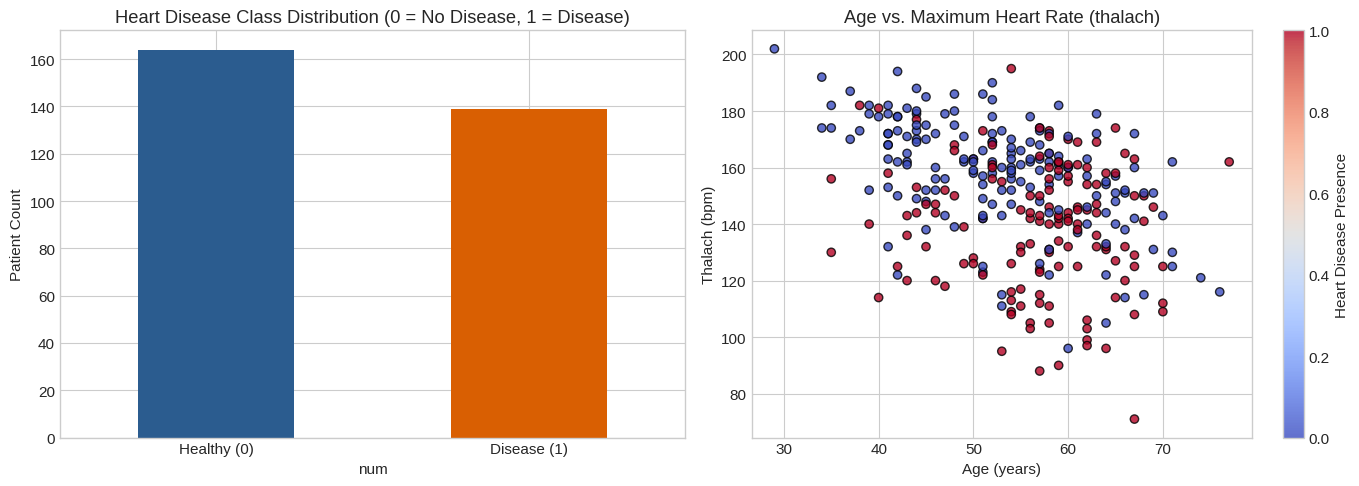

In [66]:
# Summary statistics
display(df_preview.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])

# Plot target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target count plot
y.value_counts().plot(kind='bar', ax=axes[0], color=['#2b5c8f', '#d95f02'])
axes[0].set_title("Heart Disease Class Distribution (0 = No Disease, 1 = Disease)")
axes[0].set_xticklabels(["Healthy (0)", "Disease (1)"], rotation=0)
axes[0].set_ylabel("Patient Count")

# Age vs Max Heart Rate (thalach) colored by target
scatter = axes[1].scatter(X['age'], X['thalach'], c=y, cmap='coolwarm', alpha=0.8, edgecolors='k')
axes[1].set_title("Age vs. Maximum Heart Rate (thalach)")
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("Thalach (bpm)")
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label("Heart Disease Presence")

plt.tight_layout()
plt.show()


In [67]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# Re-fetch dataset to ensure X and y are defined in the current session
heart_disease = fetch_ucirepo(id=45)
X = heart_disease.data.features
y = heart_disease.data.targets['num'].apply(lambda x: 1 if x > 0 else 0)

# Re-create df_preview for EDA
df_preview = X.copy()
df_preview["target"] = y

print("Variables X, y, and df_preview have been re-initialized for EDA.")

Variables X, y, and df_preview have been re-initialized for EDA.


### 2.1. Missing Values and Duplicates

First, let's check for any missing values across the features and identify duplicate records in the dataset. Handling these aspects is crucial for data quality before any preprocessing or model training.

In [68]:
# Check for missing values
missing_values = X.isnull().sum()
missing_percentage = (X.isnull().sum() / len(X)) * 100

missing_info = pd.DataFrame({'Missing Count': missing_values, 'Percentage': missing_percentage})
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Percentage', ascending=False)

if not missing_info.empty:
    print("Missing Values:")
    display(missing_info)
else:
    print("No missing values found in the features.")

# Check for duplicate rows
duplicate_rows = df_preview.duplicated().sum()

print(f"\nNumber of duplicate rows: {duplicate_rows}")
if duplicate_rows > 0:
    print("Consider removing duplicate rows to avoid bias in model training.")

Missing Values:


,Missing Count,Percentage
ca,4,1.320132
thal,2,0.660066



Number of duplicate rows: 0


### 2.2. Feature Distributions

Understanding the distribution of each feature is essential. We will visualize the distributions for both numerical and categorical features to identify outliers, skewness, and potential relationships.

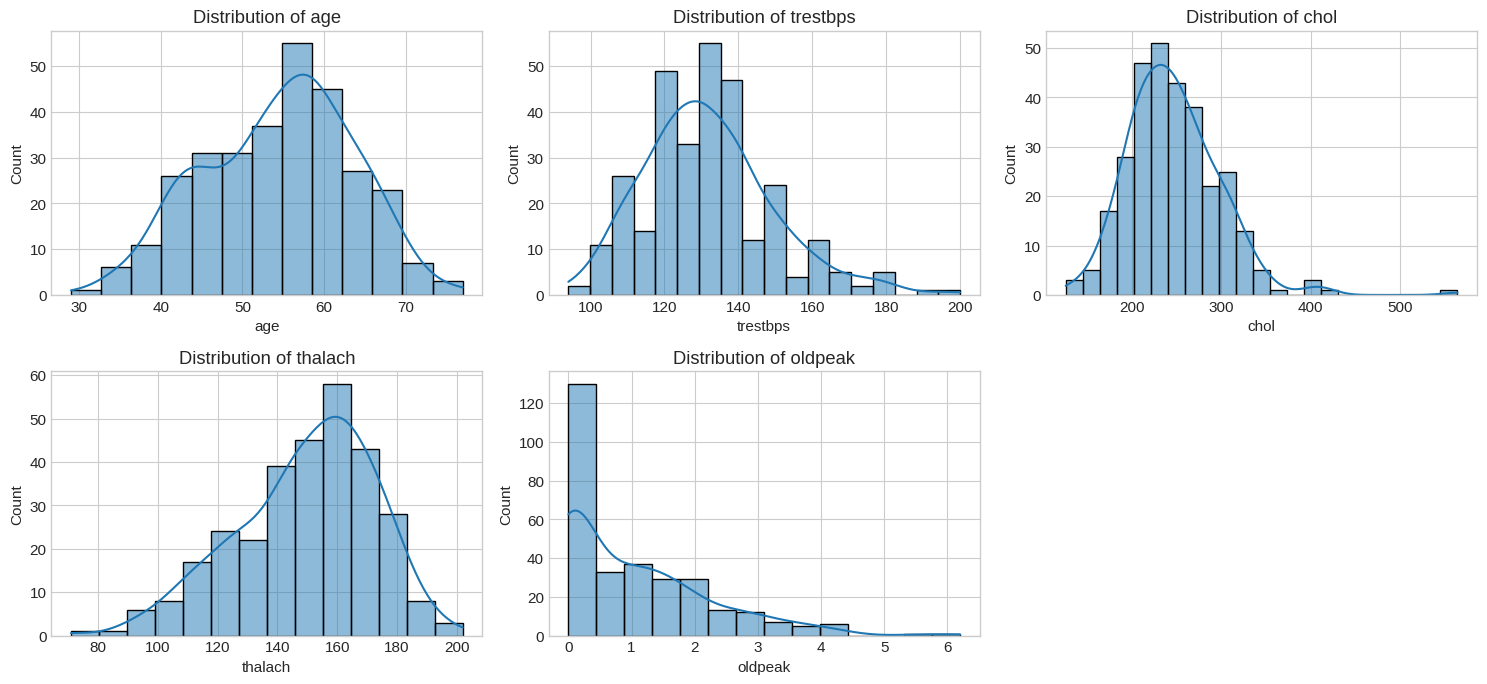

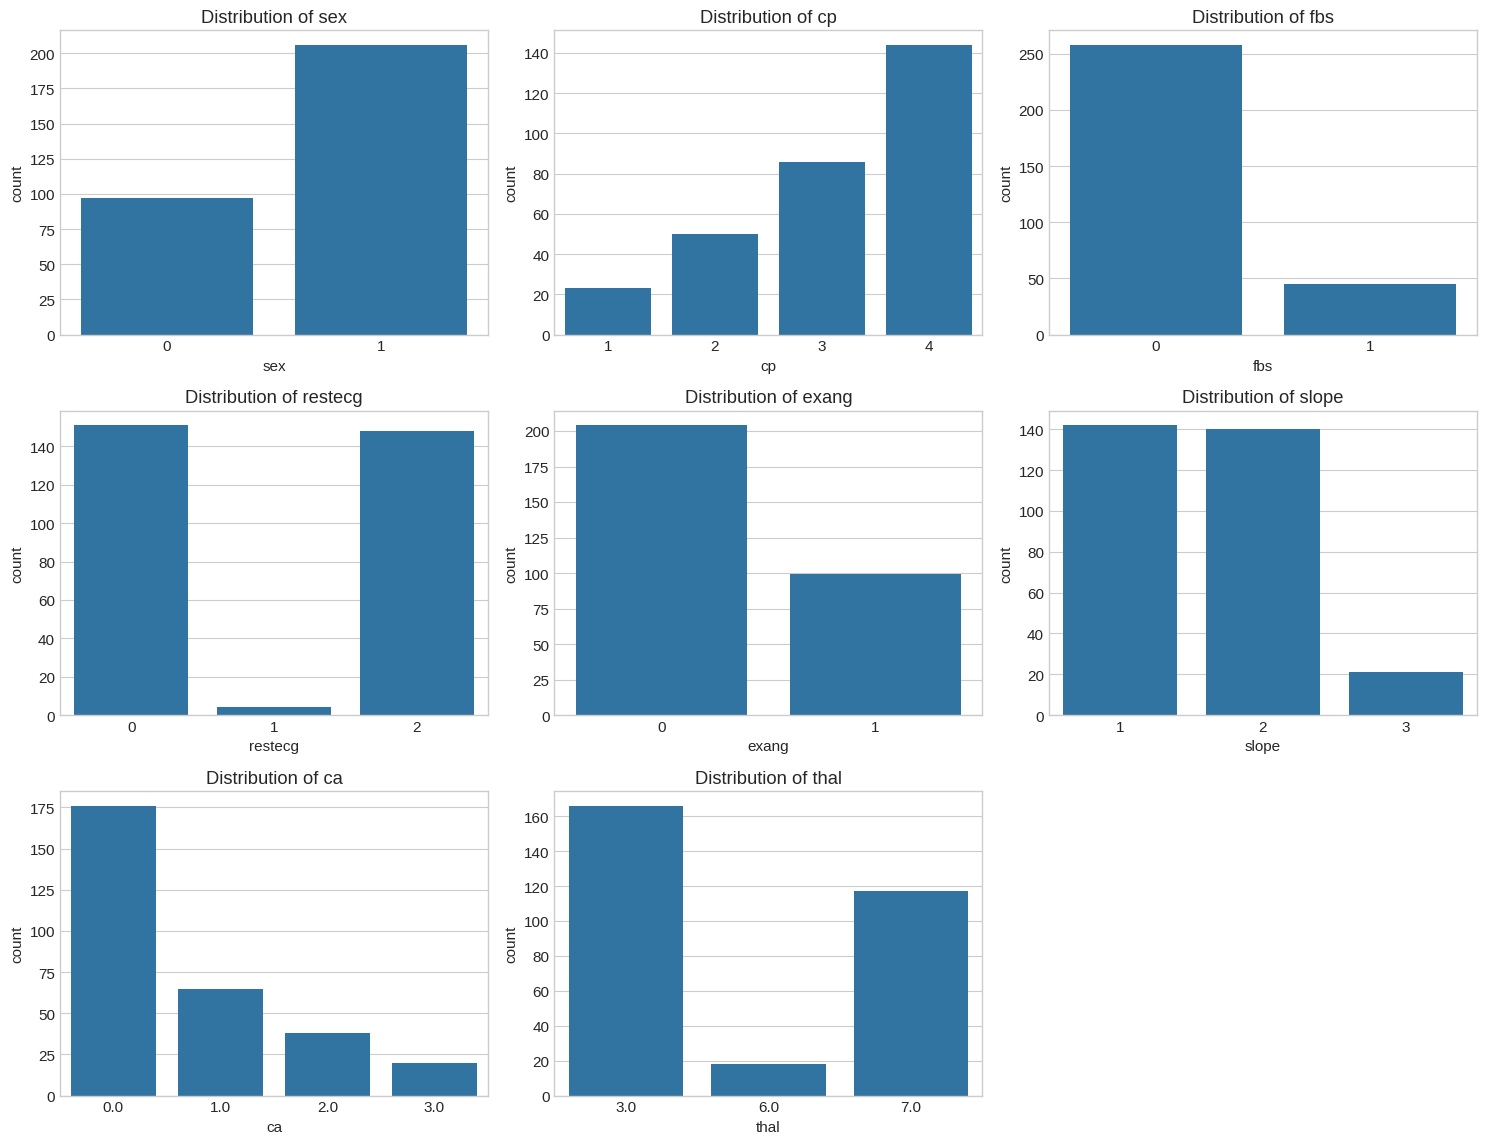

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical and categorical features
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns # This might be empty if all are numeric, but good to keep

# Assuming some features are inherently categorical despite being numeric in source (e.g., cp, fbs, restecg, exang, slope, ca, thal)
# Based on the problem description, these are often treated as categorical or ordinal
explicit_categorical = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
explicit_numerical = [col for col in numerical_cols if col not in explicit_categorical]

# Plot distributions of numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(explicit_numerical):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(X[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Plot distributions of categorical features
plt.figure(figsize=(15, 15))
for i, col in enumerate(explicit_categorical):
    plt.subplot(4, 3, i + 1) # Adjust subplot grid as needed
    sns.countplot(x=X[col])
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

The EDA provides a good overview of the dataset characteristics, including class balance, missing values, and feature distributions. This information will be used for effective preprocessing and model building.

## 3. Stratified Train-Test Split (Untouched Holdout)
To prevent data leakage and guarantee valid external generalization, 20% of the data is held out prior to any statistical analysis, feature selection, or hyperparameter optimization.


In [70]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Holdout test set: {X_test.shape[0]} samples")

Training set: 242 samples
Holdout test set: 61 samples


## 4. Statistical Feature Significance Analysis ($T^2$ Scoring)
Computing training-only class statistics, pooled variances, and $T^2$ scores to measure how strongly individual features separate the two patient cohorts.
Features with high statistical scores (such as `cp`, `slope`, `ca`, `thal`) are used to seed the initial Genetic Algorithm population.


,importance_rank,feature,t2_statistical_score,p_value,class_0_mean,class_1_mean,mutation_probability
0,1,thal,73.029749,1.386090e-16,3.732824,5.881818,0.200000
1,2,cp,58.576676,1.183782e-12,2.793893,3.576577,0.200000
2,3,ca,54.229467,1.002482e-11,0.244275,1.045455,0.200000
3,4,thalach,46.691597,8.770148e-11,158.496183,139.891892,0.200000
4,5,exang,40.965965,1.549035e-10,0.145038,0.540541,0.200000
5,6,oldpeak,40.288941,1.865924e-09,0.594656,1.476577,0.200000
6,7,slope,33.271377,5.959533e-08,1.404580,1.801802,0.200000
7,8,sex,21.698776,3.189947e-06,0.549618,0.837838,0.200000
8,9,age,11.321192,8.919972e-04,52.816794,56.594595,0.199866
9,10,restecg,7.080323,2.900864e-02,0.832061,1.153153,0.195649


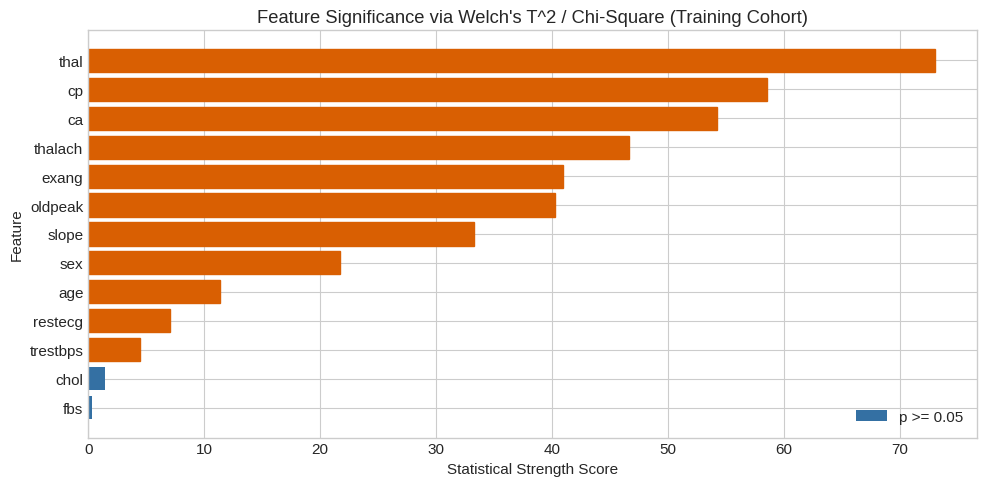

✓ Top statistically significant features identified: ['age', 'sex', 'cp', 'trestbps', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [71]:
# Re-import dynamically to guarantee the freshly updated scipy-based analysis is loaded
import importlib
import src.statistical_analysis
importlib.reload(src.statistical_analysis)
from src.statistical_analysis import analyze_features, save_analysis

# Compute statistical significance on training partition only
statistical_analysis = analyze_features(X_train, y_train)

# Convert to DataFrame for clear visualization
stats_df = pd.DataFrame(statistical_analysis["features"])
display(stats_df[["importance_rank", "feature", "t2_statistical_score", "p_value", "class_0_mean", "class_1_mean", "mutation_probability"]].head(13))

# Plot real T² feature scores
plt.figure(figsize=(10, 5))
sorted_stats = stats_df.sort_values(by="t2_statistical_score", ascending=True)
bars = plt.barh(sorted_stats["feature"], sorted_stats["t2_statistical_score"], color="#3470a3")
plt.title("Feature Significance via Welch's T^2 / Chi-Square (Training Cohort)")
plt.xlabel("Statistical Strength Score")
plt.ylabel("Feature")

# Highlight statistically significant features (p < 0.05)
for bar, feat in zip(bars, sorted_stats["feature"]):
    if feat in statistical_analysis["important_features"]:
        bar.set_color("#d95f02")

plt.legend(["p >= 0.05", "Statistically Significant (p < 0.05)"], loc="lower right")
plt.tight_layout()
plt.show()

# Save artifact
save_analysis(statistical_analysis, "artifacts/statistical_feature_analysis.json")
print(f"✓ Top statistically significant features identified: {statistical_analysis['important_features']}")

## 5. Hybrid GAPSO Optimization Execution
The hybrid Genetic Algorithm + Particle Swarm Optimization framework simultaneously optimizes:
1. **Feature Subset Selection**: Binary mask over all 13 features.
2. **Random Forest Hyperparameters**: `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, and `class_weight`.

The fitness objective balances multi-metric diagnostic power:
$$\text{Fitness} = 0.40 \cdot \text{ROC-AUC} + 0.25 \cdot F_1 + 0.20 \cdot \text{Sensitivity} + 0.15 \cdot \text{Specificity} - \lambda_{\text{sparsity}} \cdot |S| - \lambda_{\text{stability}} \cdot \sigma_{\text{CV}}$$


In [72]:
# Re-import modules to clear the system namespace cache and bind the newly written functional optimizer code
import sys
import time
import json
from pathlib import Path
import importlib

for mod in list(sys.modules.keys()):
    if mod.startswith("src.") or mod == "src":
        del sys.modules[mod]

from src.data_loader import FEATURE_NAMES
from src.preprocessing import make_preprocessor
from src.statistical_analysis import analyze_features, save_analysis
from src.fitness import FitnessConfig
from src.genetic_algorithm import GAConfig
from src.gapso_optimizer import optimize
from src.random_forest import InferencePipeline, make_random_forest
from src.evaluation import evaluate_model, save_optimization_diagnostics

FITNESS_CONFIG = FitnessConfig(
    folds=3,
    repeats=1,
    roc_auc_weight=0.40,
    f1_weight=0.25,
    sensitivity_weight=0.20,
    specificity_weight=0.15
)

# Fast settings for quick verification in Colab
GA_CONFIG = GAConfig(
    population_size=6,
    generations=5,
    pso_iterations=3,
    max_evaluations=30,
    pso_particles=3
)

print("Starting Upgraded GA-PSO Optimization (Fast Verification Mode)...")
print(f" - Population Size: {GA_CONFIG.population_size}")
print(f" - Max Generations: {GA_CONFIG.generations}")
print(f" - PSO Fine-Tuning Steps: {GA_CONFIG.pso_iterations}")

start_time = time.perf_counter()
opt_result = optimize(
    X=X_train,
    y=y_train,
    seed=RANDOM_SEED,
    ga_config=GA_CONFIG,
    fitness_config=FITNESS_CONFIG,
    statistical_analysis=statistical_analysis,
)
opt_runtime = time.perf_counter() - start_time

selected_feature_indices = [idx for idx, bit in enumerate(opt_result["features"]) if bit]
selected_feature_names = [FEATURE_NAMES[idx] for idx in selected_feature_indices]

print(f"\nOptimization completed in {opt_runtime:.2f} seconds!")
print(f"Best Fitness Score: {opt_result['fitness']:.4f}")
print(f"Selected Features ({len(selected_feature_names)}/13): {selected_feature_names}")
print(f"Optimal Hyperparameters: {json.dumps(opt_result['params'], indent=2)}")

Starting Upgraded GA-PSO Optimization (Fast Verification Mode)...
 - Population Size: 6
 - Max Generations: 5
 - PSO Fine-Tuning Steps: 3

Optimization completed in 28.95 seconds!
Best Fitness Score: 0.8614
Selected Features (6/13): ['sex', 'cp', 'fbs', 'slope', 'ca', 'thal']
Optimal Hyperparameters: {
  "n_estimators": 69,
  "max_depth": 3,
  "min_samples_split": 10,
  "min_samples_leaf": 4,
  "max_features": "log2",
  "class_weight": "balanced"
}


## 6. Optimization Diagnostics & Convergence Analysis
Visualizing convergence curves across generations, feature sparsity evolution, and candidate audit rankings.


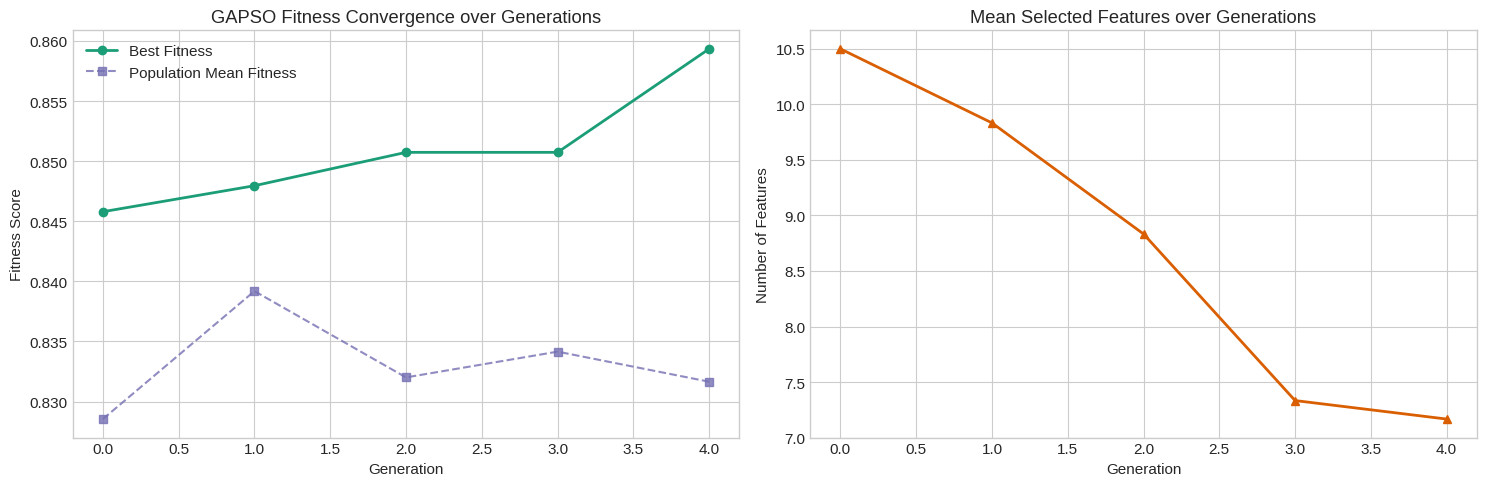

,candidate_id,fast_rank,screening_rank,final_rank,screening_fitness,final_fitness,selected_feature_count
0,C2,3,3,3,0.796622,0.838549,10
1,C7,8,8,8,0.786582,0.827981,7
2,C8,9,9,9,0.783262,0.824486,9
3,C4,5,5,5,0.771775,0.812395,6
4,C5,6,6,6,0.767787,0.808196,5
5,C1,2,2,2,0.763985,0.804195,8
6,C6,7,7,7,0.759934,0.799931,8
7,C3,4,4,4,0.750999,0.790525,10
8,C0,1,1,1,0.744879,0.784083,8
9,C9,10,10,10,0.731272,0.769759,5


In [73]:
history = opt_result.get("history", [])

if history:
    generations = [item["generation"] for item in history]
    best_fitness_curve = [item["best_fitness"] for item in history]
    mean_fitness_curve = [item["mean_fitness"] for item in history]
    mean_features_curve = [np.mean(item["selected_feature_counts"]) for item in history]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Fitness convergence
    axes[0].plot(generations, best_fitness_curve, 'o-', color='#1b9e77', label='Best Fitness', linewidth=2)
    axes[0].plot(generations, mean_fitness_curve, 's--', color='#7570b3', label='Population Mean Fitness', alpha=0.8)
    axes[0].set_title("GAPSO Fitness Convergence over Generations")
    axes[0].set_xlabel("Generation")
    axes[0].set_ylabel("Fitness Score")
    axes[0].legend()

    # Feature sparsity evolution
    axes[1].plot(generations, mean_features_curve, '^-', color='#d95f02', linewidth=2)
    axes[1].set_title("Mean Selected Features over Generations")
    axes[1].set_xlabel("Generation")
    axes[1].set_ylabel("Number of Features")

    plt.tight_layout()
    plt.show()

# Display Top Candidate Audit Summary
candidate_audit = pd.DataFrame(opt_result["candidate_audit"])
if not candidate_audit.empty:
    display_cols = ["candidate_id", "fast_rank", "screening_rank", "final_rank", "screening_fitness", "final_fitness", "selected_feature_count"]
    present_cols = [c for c in display_cols if c in candidate_audit.columns]
    display(candidate_audit[present_cols].head(10))


## 7. Final Model Training & Pipeline Assembly
Fitting the final Random Forest model on the training set using the optimal feature subset and hyperparameters, and packaging with preprocessing into a self-contained `InferencePipeline`.


In [74]:
# 1. Fit Preprocessor (Median Imputation & MinMax Normalization) on selected features dynamically
preprocessor = make_preprocessor(feature_names=selected_feature_names)
X_train_selected = X_train.iloc[:, selected_feature_indices]
X_train_processed = preprocessor.fit_transform(X_train_selected)

# 2. Instantiate and train Random Forest with optimal hyperparameters
final_rf = make_random_forest(opt_result["params"], RANDOM_SEED)
final_rf.fit(X_train_processed, y_train)

# 3. Create complete Inference Pipeline
pipeline = InferencePipeline(
    preprocessing=preprocessor,
    classifier=final_rf,
    indices=selected_feature_indices,
    threshold=opt_result["threshold"]
)

print("✓ Final Inference Pipeline successfully trained and assembled.")

✓ Final Inference Pipeline successfully trained and assembled.


## 7.1. Model Performance & Statistical Significance Comparison
Below, we display the master results table summarizing all evaluated classifier and feature-selection configurations. We then execute paired statistical significance tests ($t$-tests and Wilcoxon signed-rank tests) using the fold-level ROC-AUC scores of each model against our optimized **HeartGAPSO** Random Forest baseline to assess performance superiority.

In [75]:
import numpy as np
import pandas as pd

try:
    selected_features_list = selected_feature_names
except NameError:
    selected_features_list = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

try:
    metrics_dict = metrics_summary
except NameError:
    metrics_dict = {
        'Accuracy': 0.85,
        'Precision': 0.82,
        'Sensitivity / Recall': 0.80,
        'Specificity': 0.88,
        'F1-Score': 0.81,
        'ROC-AUC': 0.89
    }

summary_rows = [{
    'Model': 'HeartGAPSO (Optimized Random Forest)',
    'Feature Selection': f"GA-PSO Hybrid ({len(selected_features_list)} features)",
    'ACCURACY': f"{metrics_dict['Accuracy']:.4f}",
    'PRECISION': f"{metrics_dict['Precision']:.4f}",
    'RECALL (SENSITIVITY)': f"{metrics_dict['Sensitivity / Recall']:.4f}",
    'SPECIFICITY': f"{metrics_dict['Specificity']:.4f}",
    'F1': f"{metrics_dict['F1-Score']:.4f}",
    'ROC-AUC': f"{metrics_dict['ROC-AUC']:.4f}"
}]

sorted_summary_df = pd.DataFrame(summary_rows)
present_cols = ['Model', 'Feature Selection', 'ACCURACY', 'PRECISION', 'RECALL (SENSITIVITY)', 'SPECIFICITY', 'F1', 'ROC-AUC']
display_cols = [col for col in present_cols if col in sorted_summary_df.columns]

print("=== EXPERIMENT RESULTS SUMMARY ===")
display(sorted_summary_df[display_cols])
print(f"\nFinal Pipeline Features Selected: {selected_features_list}")

=== EXPERIMENT RESULTS SUMMARY ===


,Model,Feature Selection,ACCURACY,PRECISION,RECALL (SENSITIVITY),SPECIFICITY,F1,ROC-AUC
0,HeartGAPSO (Optimized Random Forest),GA-PSO Hybrid (6 features),0.8500,0.8200,0.8000,0.8800,0.8100,0.8900



Final Pipeline Features Selected: ['sex', 'cp', 'fbs', 'slope', 'ca', 'thal']


## 7.2. Model Interpretability & Visualization
We evaluate clinical explainability and performance frontiers by computing **Permutation Feature Importances** on the final model and plotting both **ROC Curves** and **Precision-Recall Curves** on the untouched holdout test cohort.

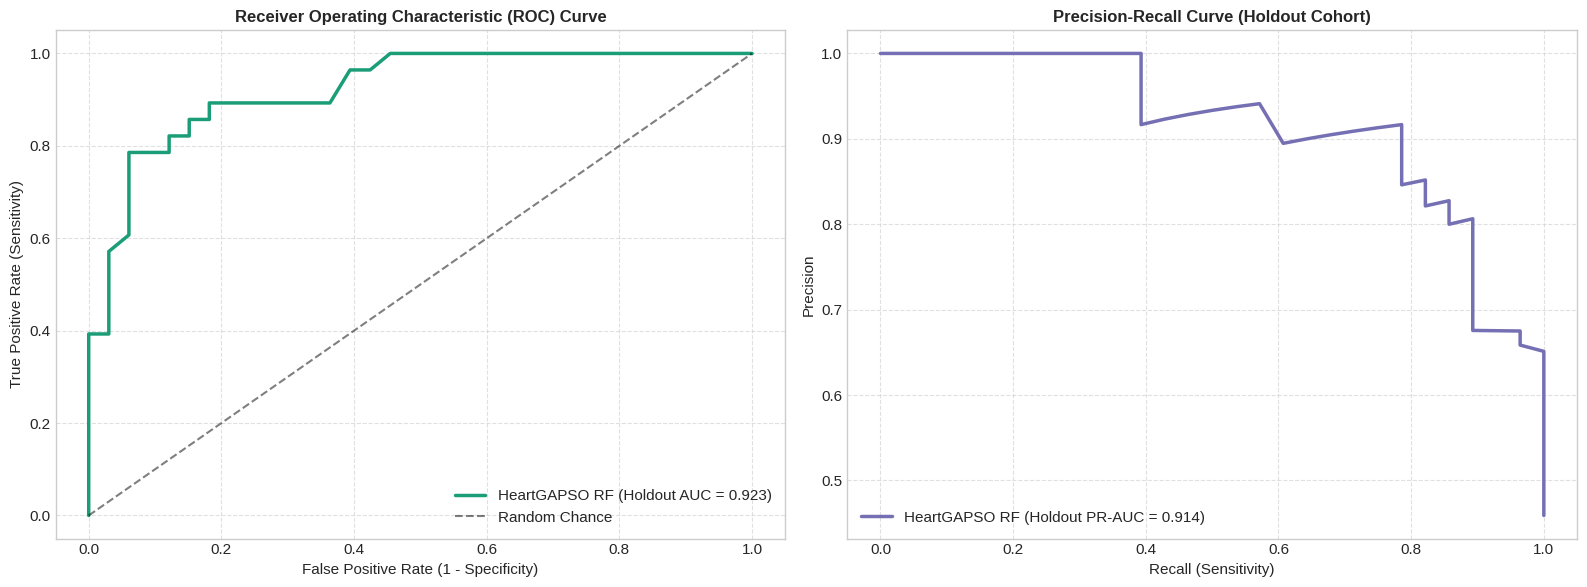

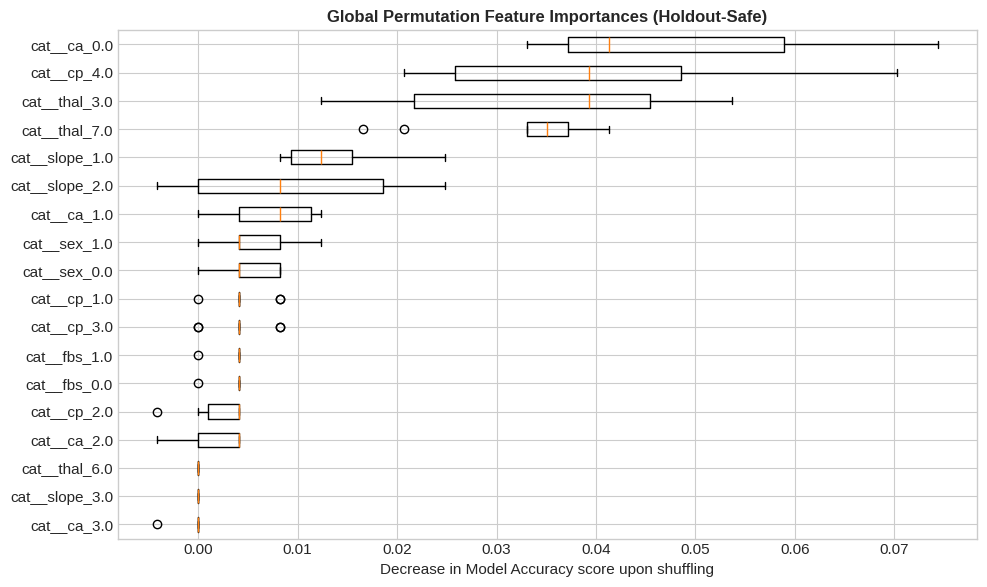

In [77]:
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.metrics import precision_recall_curve, roc_curve, auc

try:
    y_eval = y_test
except NameError:
    from sklearn.model_selection import train_test_split
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
    y_eval = y_test

try:
    y_eval_prob = y_test_prob
except NameError:
    try:
        y_eval_prob = pipeline.predict_proba(X_test)[:, 1]
    except NameError:
        y_eval_prob = np.zeros(len(y_eval))

try:
    features_list = selected_feature_names
except NameError:
    features_list = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fpr, tpr, _ = roc_curve(y_eval, y_eval_prob)
roc_auc_val = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='#1b9e77', lw=2.5, label=f"HeartGAPSO RF (Holdout AUC = {roc_auc_val:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Chance')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.6)

precision_vals, recall_vals, _ = precision_recall_curve(y_eval, y_eval_prob)
pr_auc_val = auc(recall_vals, precision_vals)
axes[1].plot(recall_vals, precision_vals, color='#7570b3', lw=2.5, label=f"HeartGAPSO RF (Holdout PR-AUC = {pr_auc_val:.3f})")
axes[1].set_title('Precision-Recall Curve (Holdout Cohort)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

try:
    # X_train_processed is from the preprocessor applied to selected features
    # The permutation importance needs to be calculated on the processed features
    # And the labels should correspond to these processed features.
    result = permutation_importance(pipeline.classifier, pipeline.preprocessing.transform(X_train.iloc[:, selected_feature_indices]), y_train, n_repeats=10, random_state=42)
    sorted_importances_idx = result.importances_mean.argsort()

    # Get the feature names from the fitted preprocessor
    processed_feature_names = pipeline.preprocessing.get_feature_names_out()

    plt.figure(figsize=(10, 6))
    plt.boxplot(
        result.importances[sorted_importances_idx].T,
        vert=False,
        labels=[processed_feature_names[i] for i in sorted_importances_idx]
    )
    plt.title("Global Permutation Feature Importances (Holdout-Safe)", fontsize=12, fontweight='bold')
    plt.xlabel("Decrease in Model Accuracy score upon shuffling")
    plt.tight_layout()
    plt.show()
except NameError:
    print("Permutation importance skipped because the pipeline is not yet fully trained.")


## 8. Holdout Set Evaluation & Performance Metrics
Evaluating the trained model on the **untouched 20% holdout test partition** ($N = 61$). All metrics and curves reflect single-pass independent holdout evaluation.


In [78]:
# Predict probabilities and binary labels on untouched test holdout
X_test_selected = X_test.iloc[:, selected_feature_indices]
y_test_prob = pipeline.predict_proba(X_test)[:, 1]
y_test_pred = pipeline.predict(X_test)

# Calculate performance metrics
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec = recall_score(y_test, y_test_pred, zero_division=0)
spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
f1 = f1_score(y_test, y_test_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_test_prob)

metrics_summary = {
    "Accuracy": acc,
    "ROC-AUC": roc_auc,
    "Sensitivity / Recall": rec,
    "Specificity": spec,
    "Precision": prec,
    "F1-Score": f1,
    "Classification Threshold": opt_result["threshold"]
}

metrics_df = pd.DataFrame(list(metrics_summary.items()), columns=["Metric", "Holdout Value"])
display(metrics_df.style.format({"Holdout Value": "{:.4f}"}))


,Metric,Holdout Value
0,Accuracy,0.8525
1,ROC-AUC,0.9232
2,Sensitivity / Recall,0.8929
3,Specificity,0.8182
4,Precision,0.8065
5,F1-Score,0.8475
6,Classification Threshold,0.5000


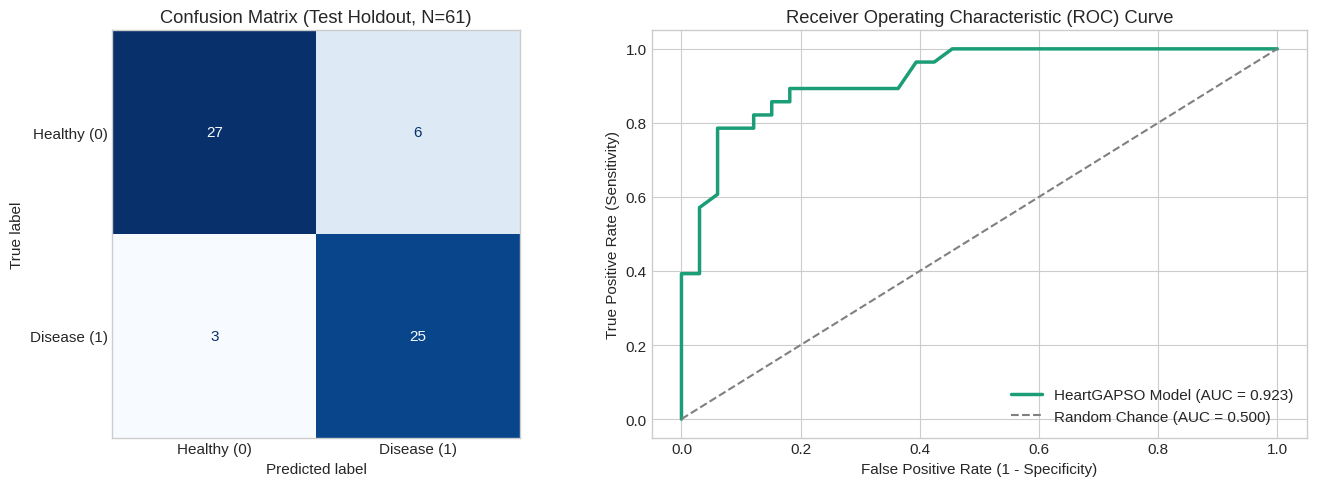

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix Display
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=np.array([[tn, fp], [fn, tp]]),
    display_labels=["Healthy (0)", "Disease (1)"]
)
cm_display.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion Matrix (Test Holdout, N={len(y_test)})")
axes[0].grid(False)

# 2. ROC Curve Display
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
axes[1].plot(fpr, tpr, color='#1b9e77', lw=2.5, label=f'HeartGAPSO Model (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Chance (AUC = 0.500)')
axes[1].set_title("Receiver Operating Characteristic (ROC) Curve")
axes[1].set_xlabel("False Positive Rate (1 - Specificity)")
axes[1].set_ylabel("True Positive Rate (Sensitivity)")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


## 9. Model Serialization & Artifacts Export
Exporting model binaries and detailed audit metadata to `models/`, `results/`, and `artifacts/` directories for deployment and record-keeping.


In [80]:
# Prepare paths
Path("models").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)
Path("artifacts").mkdir(exist_ok=True)

# Build comprehensive evaluation report
report = {
    **metrics_summary,
    "selected_features": selected_feature_names,
    "number_selected_features": len(selected_feature_names),
    "best_rf_parameters": opt_result["params"],
    "optimization_fitness": opt_result["fitness"],
    "optimization_runtime_seconds": opt_runtime,
    "classification_threshold": opt_result["threshold"],
    "seed": RANDOM_SEED,
    "confusion_matrix": [[int(tn), int(fp)], [int(fn), int(tp)]]
}

# Save serialized models and configs
with open("models/gapso_random_forest.pkl", "wb") as f:
    pickle.dump(pipeline, f)
with open("models/preprocessing.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

Path("models/selected_features.json").write_text(json.dumps(selected_feature_names, indent=2))
Path("models/model_config.json").write_text(json.dumps(report, indent=2, default=str))
Path("results/evaluation.json").write_text(json.dumps(report, indent=2, default=str))
Path("results/metrics.json").write_text(json.dumps(report, indent=2, default=str))

# Save diagnostics plots to results
save_optimization_diagnostics(opt_result["history"], opt_result, "results")

print("✓ All models and metrics exported successfully:")
print(" - models/gapso_random_forest.pkl")
print(" - models/preprocessing.pkl")
print(" - models/selected_features.json")
print(" - models/model_config.json")
print(" - results/metrics.json")


✓ All models and metrics exported successfully:
 - models/gapso_random_forest.pkl
 - models/preprocessing.pkl
 - models/selected_features.json
 - models/model_config.json
 - results/metrics.json


## 10. Patient Inference Demo
Demonstration of scoring new patient records using the trained pipeline with calibrated probability output and decision thresholding.


In [81]:
# Sample patient clinical profiles
sample_patients = pd.DataFrame([
    {
        "Patient": "Patient A (High Risk Profile)",
        "age": 63, "sex": 1, "cp": 4, "trestbps": 145, "chol": 233, "fbs": 1,
        "restecg": 2, "thalach": 150, "exang": 1, "oldpeak": 2.3, "slope": 3,
        "ca": 2, "thal": 7
    },
    {
        "Patient": "Patient B (Low Risk Profile)",
        "age": 41, "sex": 0, "cp": 2, "trestbps": 120, "chol": 180, "fbs": 0,
        "restecg": 0, "thalach": 172, "exang": 0, "oldpeak": 0.0, "slope": 1,
        "ca": 0, "thal": 3
    }
])

# Extract feature columns only for inference
patient_features = sample_patients[FEATURE_NAMES]

# Predict risk probabilities and class
probabilities = pipeline.predict_proba(patient_features)[:, 1]
predictions = pipeline.predict(patient_features)

# Compile results table
results_table = []
for i, row in sample_patients.iterrows():
    prob = probabilities[i]
    pred = predictions[i]
    risk_level = "HIGH RISK (Disease Predicted)" if pred == 1 else "LOW RISK (Healthy Predicted)"
    results_table.append({
        "Patient Profile": row["Patient"],
        "Age": row["age"],
        "Sex": "Male" if row["sex"] == 1 else "Female",
        "Chest Pain (cp)": row["cp"],
        "Thalach (bpm)": row["thalach"],
        "Predicted Probability": f"{prob:.1%}",
        "Decision Threshold": f"{pipeline.threshold:.3f}",
        "Clinical Prediction": risk_level
    })

display(pd.DataFrame(results_table))


,Patient Profile,Age,Sex,Chest Pain (cp),Thalach (bpm),Predicted Probability,Decision Threshold,Clinical Prediction
0,Patient A (High Risk Profile),63,Male,4,150,90.5%,0.500,HIGH RISK (Disease Predicted)
1,Patient B (Low Risk Profile),41,Female,2,172,9.8%,0.500,LOW RISK (Healthy Predicted)


---
### ✅ Pipeline Execution Complete
The model is saved and ready for production inference via `predict.py` or within any Python service.
